# Cicero Digital – Session 4: LatinCy → CoNLL-U → BERTopic

In diesem Notebook gehst du **einen Schritt weiter** als im spaCy/LatinCy-Notebook:

1. Du lädst das in der vorherigen Session erzeugte Brief-Dataset.
2. Du analysierst die Briefe mit **LatinCy / spaCy**.
3. Du speicherst die linguistische Annotation als **CoNLL-U**.
4. Du bereitest die Texte für **Topic Modelling** vor.
5. Du modellierst Topics mit **BERTopic** und visualisierst sie auf verschiedene Arten.

Die Idee ist methodisch bewusst einfach gehalten: erst eine **transparente Vorverarbeitung**, dann ein **exploratives Topic Modelling**.


## 0. Setup

Wir brauchen:

- `pandas` für Tabellen
- `spaCy` + möglichst `LatinCy` für die lateinische Vorverarbeitung
- `bertopic` für Topic Modelling
- `sentence-transformers` für Embeddings
- `matplotlib` und `seaborn` für Visualisierungen

**Hinweis:** Gerade bei BERTopic kann die Installation je nach Umgebung etwas dauern.


In [1]:
from pathlib import Path
import re
import math
import json
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import spacy
from spacy import displacy

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)


### Optional: Installation (falls nötig)

Diese Zelle ist nur für lokale Umgebungen gedacht. In vielen Jupyter-Setups ist bereits alles installiert.


In [2]:
# OPTIONAL: nur ausführen, falls Pakete fehlen
# !pip install spacy pandas numpy matplotlib seaborn conllu bertopic sentence-transformers umap-learn hdbscan
# Optional LatinCy-Modell:
# !pip install https://huggingface.co/latincy/la_core_web_lg/resolve/main/la_core_web_lg-any-py3-none-any.whl


## 1. Brief-CSV einlesen

Wir gehen wie im vorherigen Notebook davon aus, dass pro Brief **eine Zeile** in einer CSV-Datei liegt, etwa:

`outputs/cicero_letters.csv`


In [148]:
csv_path = Path("outputs") / "cicero_letters.csv"
df = pd.read_csv(csv_path)
df.head(3)


,corpus,book_n,letter_n,sender,recipient,date_when,year,dateline,text
0,ad_familiares,1.0,1,NaN,NaN,-56.0,-56.0,Scr. Romae Id. Ian. a. u. c. 698 (a. Chr. 56) .,"ego omni officio ac potius pietate erga te ceteris satis facio omnibus, mihi ipse numquam satis facio; tanta enim ma..."
1,ad_familiares,1.0,2,M. CICERO,P. LENTVLO PROCOS,NaN,NaN,Scr. Romae a. d. xvi Kal. Febr. a. 698 (56).,"Idibus Ianuariis in senatu nihil est confectum, propterea quod dies magna ex parte consumptus est altercatione Lentu..."
2,ad_familiares,1.0,3,M. CICERO,P. LENTVLO PROCOS,-56.0,-56.0,Scr. Romae medio mense Ian. a. 698 (56) .,"A. Trebonio, qui in tua provincia magna negotia et ampla I et expedita habet, multos annos utor valde familiariter. ..."


In [149]:
df.columns.tolist()


['corpus',
 'book_n',
 'letter_n',
 'sender',
 'recipient',
 'date_when',
 'year',
 'dateline',
 'text']

Ein paar schnelle Checks:
- Wie viele Briefe haben wir?
- Welche Subkorpora gibt es?
- Gibt es leere Texte?


In [150]:
len(df), df["corpus"].value_counts().head(20), (df["text"].fillna("").str.len() == 0).sum()


(930,
 corpus
 ad_atticum            446
 ad_familiares         431
 ad_quintum_fratrem     27
 ad_m_brutum            26
 Name: count, dtype: int64,
 0)

## 2. Arbeitsverzeichnisse anlegen

Wir speichern die Ergebnisse in einem eigenen Ordner.


In [139]:
base_out = Path("outputs")
conllu_dir = base_out / "conllu_letters"
topic_dir = base_out / "topic_modeling"

conllu_dir.mkdir(parents=True, exist_ok=True)
topic_dir.mkdir(parents=True, exist_ok=True)

conllu_dir, topic_dir


(PosixPath('outputs/conllu_letters'), PosixPath('outputs/topic_modeling'))

## 3. LatinCy initialisieren

Wir versuchen zuerst, ein lateinisches Modell zu laden. Wenn das nicht klappt, fällt das Notebook auf eine minimale `blank("la")`-Pipeline zurück.

**Wichtig:** Für gute Lemmata, POS-Tags und vor allem Dependenzen brauchst du ein echtes lateinisches Modell.


In [154]:
def load_nlp():
    model_candidates = [
        "la_core_web_lg",
        "la_core_web_md",
        "la_core_web_sm",
    ]
    for name in model_candidates:
        try:
            nlp = spacy.load(name)
            print(f"Loaded model: {name}")
            return nlp
        except Exception:
            pass

    print("Kein LatinCy-Modell gefunden. Nutze spaCy blank('la') als Fallback.")
    nlp = spacy.blank("la")
    if "sentencizer" not in nlp.pipe_names:
        nlp.add_pipe("sentencizer")
    return nlp

nlp = load_nlp()
nlp.pipe_names


Loaded model: la_core_web_lg


['senter',
 'normer',
 'tok2vec',
 'tagger',
 'morphologizer',
 'trainable_lemmatizer',
 'parser',
 'lookup_lemmatizer',
 'ner',
 'remorpher']

## 4. Einen Brief probeweise analysieren

Wir schauen uns zuerst **einen** Brief an, bevor wir die ganze Sammlung durchlaufen.


In [155]:
example = df.iloc[0]
example[["corpus", "book_n", "letter_n"] if {"corpus", "book_n", "letter_n"}.issubset(df.columns) else df.columns[:3]].to_dict()


{'corpus': 'ad_familiares', 'book_n': 1.0, 'letter_n': '1'}

In [156]:
doc = nlp(str(example["text"]))
[(t.text, t.lemma_, t.pos_, t.dep_) for t in doc[:25]]


[('ego', 'ego', 'PRON', 'nsubj'),
 ('omni', 'omnis', 'DET', 'det'),
 ('officio', 'officium', 'NOUN', 'obl'),
 ('ac', 'ac', 'CCONJ', 'cc'),
 ('potius', 'potior', 'ADV', 'advmod'),
 ('pietate', 'pietas', 'NOUN', 'conj'),
 ('erga', 'erga', 'ADP', 'case'),
 ('te', 'tu', 'PRON', 'obl'),
 ('ceteris', 'ceterus', 'NOUN', 'obl'),
 ('satis', 'satisfacio', 'ADV', 'ccomp'),
 ('facio', 'facio', 'VERB', 'ROOT'),
 ('omnibus', 'omnis', 'DET', 'obl:arg'),
 (',', ',', 'PUNCT', 'punct'),
 ('mihi', 'ego', 'PRON', 'obl:arg'),
 ('ipse', 'ipse', 'DET', 'det'),
 ('numquam', 'numquam', 'ADV', 'advmod'),
 ('satis', 'satis', 'ADV', 'xcomp'),
 ('facio', 'facio', 'VERB', 'conj'),
 (';', ';', 'PUNCT', 'punct'),
 ('tanta', 'tantus', 'DET', 'det'),
 ('enim', 'enim', 'PART', 'discourse'),
 ('magnitudo', 'magnitudo', 'NOUN', 'nsubj'),
 ('est', 'sum', 'AUX', 'cop'),
 ('tuorum', 'tuus', 'DET', 'nmod'),
 ('erga', 'erga', 'ADP', 'case')]

In [157]:
list(doc.sents)[:2]


[ego omni officio ac potius pietate erga te ceteris satis facio omnibus, mihi ipse numquam satis facio;,
 tanta enim magnitudo est tuorum erga me meritorum, ut, quod tu nisi perfecta re de me non conquiesti, ego quia non idem in tua causa efficio, vitam mihi esse acerbam putem.]

### Optional: Parsingbaum anzeigen

Diese Visualisierung funktioniert am besten, wenn das geladene Modell wirklich Dependenzen liefert.


In [158]:
first_sent = list(doc.sents)[0]
displacy.render(first_sent, style="dep", jupyter=True)


## 5. CoNLL-U Export vorbereiten

Jetzt bauen wir eine kleine Funktion, die einen `spaCy`-`Doc` in ein **CoNLL-U-ähnliches Format** überführt.

Dabei gilt:
- `FORM` = Oberflächenform
- `LEMMA` = Lemma
- `UPOS` = Universal POS
- `HEAD` und `DEPREL` nur, falls vorhanden
- Metadaten (`sent_id`, `text`) werden als Kommentarzeilen vor jeden Satz geschrieben


In [159]:
def escape_conllu_text(text: str) -> str:
    return text.replace("\n", " ").strip()

def token_to_conllu_line(token):
    # HEAD: CoNLL-U zählt ab 1, ROOT = 0
    if token.dep_ and token.dep_.upper() != "ROOT":
        head = token.head.i - token.sent.start + 1
    elif token.dep_.upper() == "ROOT":
        head = 0
    else:
        head = "_"

    fields = [
        str(token.i - token.sent.start + 1),                    # ID
        token.text if token.text else "_",                     # FORM
        token.lemma_ if token.lemma_ else "_",                 # LEMMA
        token.pos_ if token.pos_ else "_",                     # UPOS
        token.tag_ if token.tag_ else "_",                     # XPOS
        "_",                                                   # FEATS
        str(head) if head != "_" else "_",                     # HEAD
        token.dep_ if token.dep_ else "_",                     # DEPREL
        "_",                                                   # DEPS
        "_"                                                    # MISC
    ]
    return "\t".join(fields)

def doc_to_conllu(doc, doc_id="doc"):
    parts = []
    for sent_i, sent in enumerate(doc.sents, start=1):
        parts.append(f"# sent_id = {doc_id}_s{sent_i}")
        parts.append(f"# text = {escape_conllu_text(sent.text)}")
        for token in sent:
            if token.is_space:
                continue
            parts.append(token_to_conllu_line(token))
        parts.append("")
    return "\n".join(parts)


In [160]:
print(doc_to_conllu(doc, doc_id="example")[:1200])


# sent_id = example_s1
# text = ego omni officio ac potius pietate erga te ceteris satis facio omnibus, mihi ipse numquam satis facio;
1	ego	ego	PRON	pronoun	_	11	nsubj	_	_
2	omni	omnis	DET	adjective	_	3	det	_	_
3	officio	officium	NOUN	noun	_	1	obl	_	_
4	ac	ac	CCONJ	conjunction	_	6	cc	_	_
5	potius	potior	ADV	adverb	_	6	advmod	_	_
6	pietate	pietas	NOUN	noun	_	3	conj	_	_
7	erga	erga	ADP	preposition	_	8	case	_	_
8	te	tu	PRON	pronoun	_	9	obl	_	_
9	ceteris	ceterus	NOUN	noun	_	10	obl	_	_
10	satis	satisfacio	ADV	adverb	_	11	ccomp	_	_
11	facio	facio	VERB	verb	_	0	ROOT	_	_
12	omnibus	omnis	DET	adjective	_	11	obl:arg	_	_
13	,	,	PUNCT	punc	_	18	punct	_	_
14	mihi	ego	PRON	pronoun	_	17	obl:arg	_	_
15	ipse	ipse	DET	determiner	_	14	det	_	_
16	numquam	numquam	ADV	adverb	_	17	advmod	_	_
17	satis	satis	ADV	adverb	_	18	xcomp	_	_
18	facio	facio	VERB	verb	_	11	conj	_	_
19	;	;	PUNCT	punc	_	11	punct	_	_

# sent_id = example_s2
# text = tanta enim magnitudo est tuorum erga me meritorum, ut, quod tu nisi perfe

## 6. Gesamtkorpus mit LatinCy verarbeiten

Wir parsen jetzt alle Briefe. Das kann je nach Korpusgrösse und Modell etwas dauern.

Zusätzlich speichern wir:
- pro Brief eine `.conllu`-Datei
- eine Metadatentabelle mit ein paar Kennzahlen


In [162]:
def make_doc_id(row, idx):
    corpus = str(row.get("corpus", "unknown")).strip()

    book_n = row.get("book_n")
    letter_n = row.get("letter_n")

    book_n = "x" if pd.isna(book_n) else str(book_n).strip()
    letter_n = str(idx) if pd.isna(letter_n) else str(letter_n).strip()

    return f"{corpus}_b{book_n}_l{letter_n}_r{idx}"

texts = df["text"].fillna("").astype(str).tolist()
doc_ids = [make_doc_id(row, idx) for idx, (_, row) in enumerate(df.iterrows())]

docs = []
meta_rows = []

for doc_id, (_, row), doc in zip(doc_ids, df.iterrows(), nlp.pipe(texts, batch_size=16)):
    docs.append(doc)

    conllu_text = doc_to_conllu(doc, doc_id=doc_id)
    (conllu_dir / f"{doc_id}.conllu").write_text(conllu_text, encoding="utf-8")

    tokens = [t for t in doc if not t.is_space]
    alpha_tokens = [t for t in tokens if t.is_alpha]
    sentences = list(doc.sents)

    meta_rows.append({
        "doc_id": doc_id,
        "corpus": row.get("corpus", None),
        "book_n": row.get("book_n", None),
        "letter_n": row.get("letter_n", None),
        "date_when": row.get("date_when", None),
        "n_tokens": len(tokens),
        "n_alpha_tokens": len(alpha_tokens),
        "n_sentences": len(sentences),
        "mean_sent_len": round(np.mean([len([t for t in s if not t.is_space]) for s in sentences]), 2) if sentences else np.nan
    })

meta = pd.DataFrame(meta_rows)
meta.head()


,doc_id,corpus,book_n,letter_n,date_when,n_tokens,n_alpha_tokens,n_sentences,mean_sent_len
0,ad_familiares_b1.0_l1_r0,ad_familiares,1.0,1,-56.0,504,424,29,17.38
1,ad_familiares_b1.0_l2_r1,ad_familiares,1.0,2,NaN,463,392,27,17.15
2,ad_familiares_b1.0_l3_r2,ad_familiares,1.0,3,-56.0,114,98,3,38.00
3,ad_familiares_b1.0_l4_r3,ad_familiares,1.0,4,NaN,299,254,17,17.59
4,ad_familiares_b1.0_l5a_r4,ad_familiares,1.0,5a,-56.0,328,285,12,27.33


In [23]:
meta_path = base_out / "cicero_letters_latincy_metadata.csv"
meta.to_csv(meta_path, index=False)

meta_path


PosixPath('outputs/cicero_letters_latincy_metadata.csv')

### Optional: alle Briefe auch als **eine** grosse CoNLL-U-Datei speichern


In [24]:
combined_conllu_path = base_out / "cicero_letters_all.conllu"

with combined_conllu_path.open("w", encoding="utf-8") as f:
    for doc_id, doc in zip(doc_ids, docs):
        f.write(doc_to_conllu(doc, doc_id=doc_id))
        f.write("\n")

combined_conllu_path


PosixPath('outputs/cicero_letters_all.conllu')

## 7. Kleine Qualitätskontrolle der Annotation

Bevor wir Topic Modelling machen, schauen wir uns an:
- POS-Verteilung insgesamt
- mittlere Satzlänge nach Subkorpus


In [25]:
pos_counter = Counter()
for doc in docs:
    for tok in doc:
        if tok.is_space:
            continue
        pos_counter[tok.pos_ if tok.pos_ else "UNK"] += 1

pos_df = (
    pd.Series(pos_counter)
    .sort_values(ascending=False)
    .rename_axis("pos")
    .reset_index(name="count")
)
pos_df.head(15)


,pos,count
0,VERB,52848
1,PUNCT,46665
2,NOUN,42466
3,PRON,34080
4,ADV,21993
5,DET,21194
6,ADP,18335
7,CCONJ,16368
8,ADJ,14600
9,SCONJ,14495


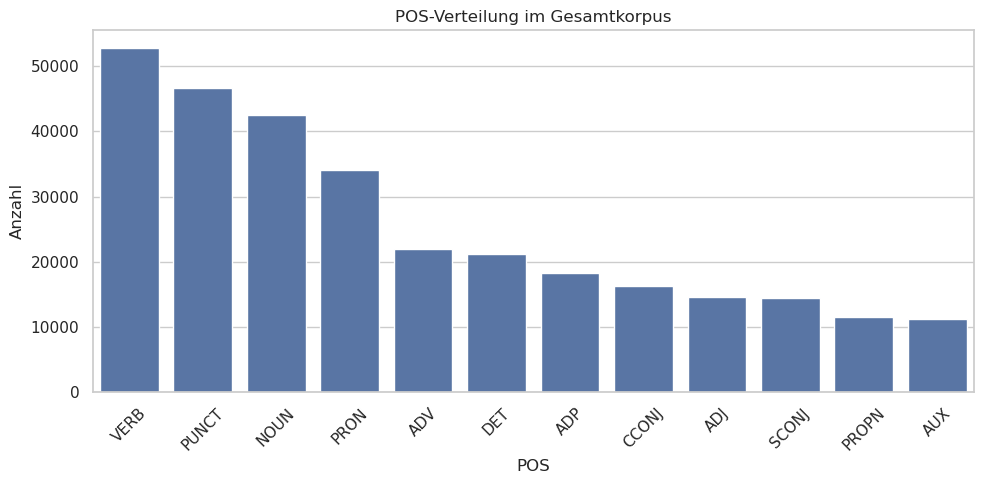

In [26]:
plt.figure(figsize=(10, 5))
sns.barplot(data=pos_df.head(12), x="pos", y="count")
plt.title("POS-Verteilung im Gesamtkorpus")
plt.xlabel("POS")
plt.ylabel("Anzahl")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


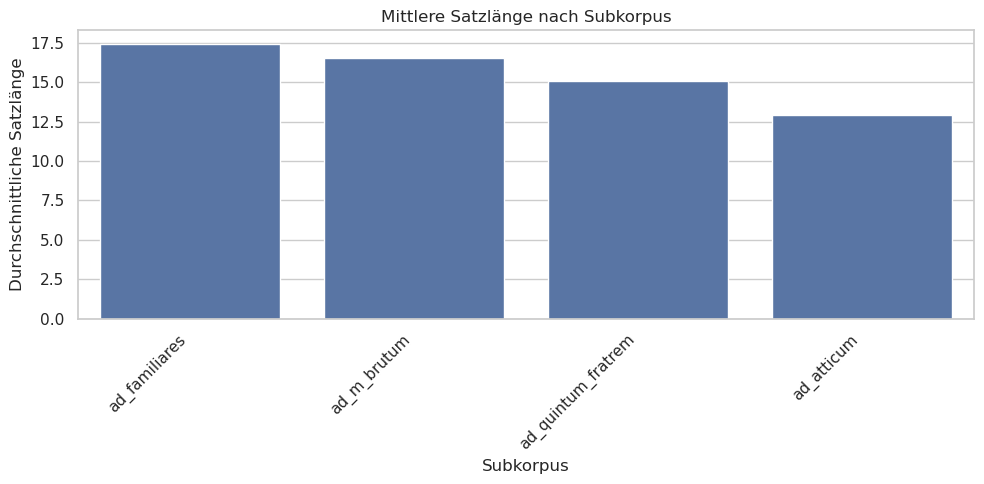

In [27]:
sent_stats = (
    meta.groupby("corpus", dropna=False)["mean_sent_len"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=sent_stats, x="corpus", y="mean_sent_len")
plt.title("Mittlere Satzlänge nach Subkorpus")
plt.xlabel("Subkorpus")
plt.ylabel("Durchschnittliche Satzlänge")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 8a. Texte laden, falls sie schon durch LatinCy gelaufen sind

Hier laden wir die Texte in einen DataFrame, falls die Wortartenannotation und die Lemmatisierung bereits erfolgt sind.

In [165]:
from pathlib import Path
from conllu import parse

conllu_dir = Path("outputs/conllu_letters")
files = sorted(conllu_dir.glob("*.conllu"))

allowed_upos = {"NOUN", "PROPN", "ADJ", "VERB"}

rows = []

for file in files:
    content = file.read_text(encoding="utf-8")
    
    try:
        sentences = parse(content)
    except Exception as e:
        print(f"Fehler bei {file.name}: {e}")
        continue

    lemmas_all = []
    lemmas_content = []

    for sent in sentences:
        for token in sent:
            if not isinstance(token["id"], int):
                continue

            lemma = token.get("lemma")
            upos = token.get("upostag") or token.get("upos")

            if lemma:
                lemmas_all.append(lemma)
                if upos in allowed_upos:
                    lemmas_content.append(lemma)

    if 'ad_atticum' in file.stem:
        corpus = 'ad_atticum'
    else:
        corpus = file.stem.split('.')[0]

    rows.append({
        "doc_id": file.stem,
        "corpus": corpus,
        "lemma_text": " ".join(lemmas_all),
        "content_lemma_text": " ".join(lemmas_content),
        "n_lemmas": len(lemmas_all),
        "n_content_lemmas": len(lemmas_content),
    })

df_loaded = pd.DataFrame(rows)

# diese Spalte dann für TF-IDF / Topic Modelling benutzen
df_loaded["clean_text"] = df_loaded["content_lemma_text"]

display(df_loaded.head())

,doc_id,corpus,lemma_text,content_lemma_text,n_lemmas,n_content_lemmas,clean_text
0,ad_atticum_bx_l10_r440,ad_atticum,"cum sum in Tusculanum _ hic tu pro ille tuus : cum sum in Ceramicus ) uerum tamen cum ibi sum , Roma puer ab soror t...",Tusculanum _ Ceramicus Roma puer soror mitto epistula adlatus do nuntio dies meridies eo proficiscor facio epistola ...,347,123,Tusculanum _ Ceramicus Roma puer soror mitto epistula adlatus do nuntio dies meridies eo proficiscor facio epistola ...
1,ad_atticum_bx_l10_r460,ad_atticum,"uolo amo meus constantia . ludus Antium specto non placeo ; sum enim _ , cum uolo uito omnis delicia suspicio , repe...",uolo amo constantia ludus Antium specto placeo _ uolo uito delicia suspicio peregrinor res nonus Maius Formianum exs...,67,28,uolo amo constantia ludus Antium specto placeo _ uolo uito delicia suspicio peregrinor res nonus Maius Formianum exs...
2,ad_atticum_bx_l10_r485,ad_atticum,"ago qui sum usque ad ante . dies . uiii Kalendae . iunius cognosco ex tuus littera ; reliquus exspecto , ut tu place...",ago dies Kalendae iunius cognosco littera reliquus exspecto placeo Thessalonica adlatus statuo possum causa ago spes...,354,114,ago dies Kalendae iunius cognosco littera reliquus exspecto placeo Thessalonica adlatus statuo possum causa ago spes...
3,ad_atticum_bx_l10_r514,ad_atticum,Puteoli magnus sum rumor Ptolomaeus sum in regnum . si quis habeo certior uolo scio . ego hic pasco bibliotheca Faus...,Puteoli magnus rumor Ptolomaeus regnum habeo certior uolo scio pasco bibliotheca Faustus puto res Puteolanus Lucrine...,151,63,Puteoli magnus rumor Ptolomaeus regnum habeo certior uolo scio pasco bibliotheca Faustus puto res Puteolanus Lucrine...
4,ad_atticum_bx_l10_r533,ad_atticum,"ut Athenae ab . dies . uis Kalendae . Quintilis uenio , exspecto ubi iam quartus dies Pomptinus neque de is aduentus...",Athenae dies Kalendae Quintilis uenio exspecto quartus dies Pomptinus aduentus certum habeo credo uestigium monitus ...,438,126,Athenae dies Kalendae Quintilis uenio exspecto quartus dies Pomptinus aduentus certum habeo credo uestigium monitus ...


In [166]:
df_loaded.describe()

,n_lemmas,n_content_lemmas
count,930.000000,930.000000
mean,342.012903,130.611828
std,364.144174,144.207835
min,2.000000,2.000000
25%,149.000000,54.000000
50%,258.500000,97.000000
75%,410.500000,156.750000
max,5122.000000,2021.000000


In [167]:
df_loaded = df_loaded.merge(
    meta[["doc_id", "date_when"]],
    on="doc_id",
    how="left"
)

In [168]:
df_loaded.head()

,doc_id,corpus,lemma_text,content_lemma_text,n_lemmas,n_content_lemmas,clean_text,date_when
0,ad_atticum_bx_l10_r440,ad_atticum,"cum sum in Tusculanum _ hic tu pro ille tuus : cum sum in Ceramicus ) uerum tamen cum ibi sum , Roma puer ab soror t...",Tusculanum _ Ceramicus Roma puer soror mitto epistula adlatus do nuntio dies meridies eo proficiscor facio epistola ...,347,123,Tusculanum _ Ceramicus Roma puer soror mitto epistula adlatus do nuntio dies meridies eo proficiscor facio epistola ...,-67.0
1,ad_atticum_bx_l10_r460,ad_atticum,"uolo amo meus constantia . ludus Antium specto non placeo ; sum enim _ , cum uolo uito omnis delicia suspicio , repe...",uolo amo constantia ludus Antium specto placeo _ uolo uito delicia suspicio peregrinor res nonus Maius Formianum exs...,67,28,uolo amo constantia ludus Antium specto placeo _ uolo uito delicia suspicio peregrinor res nonus Maius Formianum exs...,NaN
2,ad_atticum_bx_l10_r485,ad_atticum,"ago qui sum usque ad ante . dies . uiii Kalendae . iunius cognosco ex tuus littera ; reliquus exspecto , ut tu place...",ago dies Kalendae iunius cognosco littera reliquus exspecto placeo Thessalonica adlatus statuo possum causa ago spes...,354,114,ago dies Kalendae iunius cognosco littera reliquus exspecto placeo Thessalonica adlatus statuo possum causa ago spes...,-58.0
3,ad_atticum_bx_l10_r514,ad_atticum,Puteoli magnus sum rumor Ptolomaeus sum in regnum . si quis habeo certior uolo scio . ego hic pasco bibliotheca Faus...,Puteoli magnus rumor Ptolomaeus regnum habeo certior uolo scio pasco bibliotheca Faustus puto res Puteolanus Lucrine...,151,63,Puteoli magnus rumor Ptolomaeus regnum habeo certior uolo scio pasco bibliotheca Faustus puto res Puteolanus Lucrine...,NaN
4,ad_atticum_bx_l10_r533,ad_atticum,"ut Athenae ab . dies . uis Kalendae . Quintilis uenio , exspecto ubi iam quartus dies Pomptinus neque de is aduentus...",Athenae dies Kalendae Quintilis uenio exspecto quartus dies Pomptinus aduentus certum habeo credo uestigium monitus ...,438,126,Athenae dies Kalendae Quintilis uenio exspecto quartus dies Pomptinus aduentus certum habeo credo uestigium monitus ...,-51.0


## 8b. Texte für Topic Modelling vorbereiten

Für Topic Modelling ist es meist sinnvoll, **nicht** die rohen Texte direkt zu nehmen, sondern eine leicht normalisierte Variante.

Hier bauen wir pro Brief einen Modelltext aus:
- **Lemmata**
- nur alphabetische Tokens
- ohne Interpunktion / Zahlen
- optional gefiltert auf inhaltstragende Wortarten

Das ist für lateinische Daten oft stabiler als rohe Wortformen.


In [172]:
import re

LATIN_STOPWORDS = {
    "et", "in", "de", "ad", "non", "ut", "cum", "qui", "quae", "quod", "est", "esse",
    "sum", "ego", "tu", "nos", "vos", "hic", "ille", "is", "ea", "id", "autem", "enim",
    "sed", "si", "ne", "nec", "nam", "ita", "iam", "me", "te", "se", "mihi", "tibi",
    "sibi", "noster", "vester", "suus", "quid", "quoniam", "quoque", "tam", "tamen",
    "apud", "ab", "a", "ex", "e", "per", "pro", "post", "ante", "inter", "sine",
    "scribo", "littera"
}

def prepare_topic_text_from_string(text, min_len=2):
    if pd.isna(text):
        return ""

    lemmas = []
    for lemma in str(text).split():
        #lemma = lemma.lower().strip()
        lemma = re.sub(r"[^a-zA-Zāēīōūȳăĕĭŏŭ]+", "", lemma)

        if len(lemma) < min_len:
            continue
        if lemma in LATIN_STOPWORDS:
            continue

        lemmas.append(lemma)

    return " ".join(lemmas)

df_topics = df_loaded.copy()
df_topics["topic_text"] = df_topics["content_lemma_text"].apply(prepare_topic_text_from_string)

df_topics[["doc_id", "topic_text"]].head()

,doc_id,topic_text
0,ad_atticum_bx_l10_r440,Tusculanum Ceramicus Roma puer soror mitto epistula adlatus do nuntio dies meridies eo proficiscor facio epistola re...
1,ad_atticum_bx_l10_r460,uolo amo constantia ludus Antium specto placeo uolo uito delicia suspicio peregrinor res nonus Maius Formianum exspe...
2,ad_atticum_bx_l10_r485,ago dies Kalendae iunius cognosco reliquus exspecto placeo Thessalonica adlatus statuo possum causa ago spes uideo o...
3,ad_atticum_bx_l10_r514,Puteoli magnus rumor Ptolomaeus regnum habeo certior uolo scio pasco bibliotheca Faustus puto res Puteolanus Lucrine...
4,ad_atticum_bx_l10_r533,Athenae dies Kalendae Quintilis uenio exspecto quartus dies Pomptinus aduentus certum habeo credo uestigium monitus ...


In [174]:
# Leere oder fast leere Dokumente ausschliessen
mask_nonempty = df_topics["topic_text"].str.strip().str.len() > 0
df_topics = df_topics.loc[mask_nonempty].reset_index(drop=True)

len(df_topics), df_topics["topic_text"].str.split().str.len().describe()


(930,
 count     930.000000
 mean      126.033333
 std       140.950968
 min         2.000000
 25%        52.250000
 50%        91.500000
 75%       150.750000
 max      2003.000000
 Name: topic_text, dtype: float64)

## 9a. TF-IDF

In [175]:
from sklearn.feature_extraction.text import TfidfVectorizer

# -----------------------------
# 1. Daten vorbereiten
# -----------------------------
texts = df_topics["topic_text"].fillna("").tolist()
doc_ids = df_topics["doc_id"].tolist()

min_words = 5
valid_idx = [i for i, text in enumerate(texts) if len(text.split()) >= min_words]

texts_net = [texts[i] for i in valid_idx]
doc_ids_net = [doc_ids[i] for i in valid_idx]

print(f"Dokumente im Netzwerk: {len(doc_ids_net)}")

# -----------------------------
# 2. TF-IDF Matrix
# -----------------------------
vectorizer = TfidfVectorizer(
    token_pattern=r"(?u)\b\w+\b",
    min_df=3,          # Wort muss in mind. 3 Briefen vorkommen
    max_df=0.5,        # extrem häufige Wörter raus
    ngram_range=(1,2)
)

tfidf_matrix = vectorizer.fit_transform(texts_net)

print("Matrix shape:", tfidf_matrix.shape)

terms = vectorizer.get_feature_names_out()

# -----------------------------
# 3. Top Wörter pro Dokument
# -----------------------------
def top_tfidf_words(doc_index, n=10):
    row = tfidf_matrix[doc_index].toarray().flatten()
    top_idx = row.argsort()[::-1][:n]
    return [(terms[i], row[i]) for i in top_idx]

Dokumente im Netzwerk: 929
Matrix shape: (929, 7960)


In [176]:
doc_index = 0
print("Document:", doc_ids[doc_index])
print(top_tfidf_words(doc_index, 10))

Document: ad_atticum_bx_l10_r440
[('pario', 0.22351513569438408), ('soror', 0.16853214635502684), ('signum', 0.1665117423921678), ('comitia', 0.15931057453619488), ('locus', 0.14396009043976724), ('confido', 0.13565590664108332), ('proficiscor facio', 0.1302664846343018), ('communis amicus', 0.1302664846343018), ('causa magnus', 0.1302664846343018), ('sponsor appello', 0.1302664846343018)]


In [177]:
doc_index = 2
print("Document:", doc_ids[doc_index])
print(top_tfidf_words(doc_index, 10))

Document: ad_atticum_bx_l10_r485
[('adlatus', 0.21106785404346048), ('thessalonica', 0.20564377893959104), ('calamitas', 0.18291206017733685), ('impedio', 0.13639652925741255), ('placeo thessalonica', 0.13097768333591917), ('ago spes', 0.13097768333591917), ('dignus puto', 0.13097768333591917), ('obiurgatio', 0.13097768333591917), ('consilium ineo', 0.13097768333591917), ('squalor', 0.13097768333591917)]


### Charakteristische Wörter pro Brief

In [178]:
rows = []

for i, doc_id in enumerate(doc_ids_net):
    top_words = top_tfidf_words(i, 5)
    for word, score in top_words:
        rows.append({
            "doc_id": doc_id,
            "word": word,
            "tfidf": score
        })

tfidf_df = pd.DataFrame(rows)

display(tfidf_df.head(20))

,doc_id,word,tfidf
0,ad_atticum_bx_l10_r440,pario,0.223515
1,ad_atticum_bx_l10_r440,soror,0.168532
2,ad_atticum_bx_l10_r440,signum,0.166512
3,ad_atticum_bx_l10_r440,comitia,0.159311
4,ad_atticum_bx_l10_r440,locus,0.143960
5,ad_atticum_bx_l10_r460,peregrinor,0.251697
6,ad_atticum_bx_l10_r460,uolo uito,0.251697
7,ad_atticum_bx_l10_r460,hora quartus,0.251697
8,ad_atticum_bx_l10_r460,uolo amo,0.242988
9,ad_atticum_bx_l10_r460,tabernae,0.242988


### Wichtigste Wörter im gesamten Korpus

,word,score
0,dies,0.026834
1,ago,0.026720
2,dico,0.026593
3,scio,0.026576
4,do,0.024868
5,causa,0.023889
6,magnus,0.023706
7,caesar,0.023348
8,homo,0.023013
9,mitto,0.021705


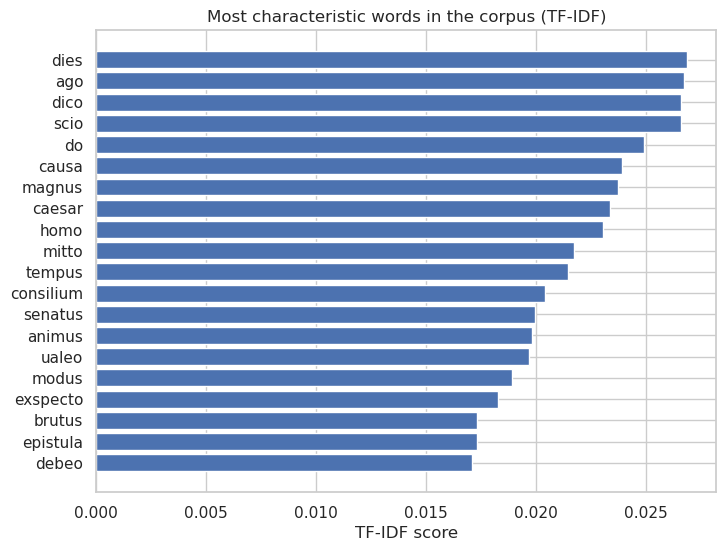

In [179]:
mean_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

top_idx = mean_scores.argsort()[::-1][:20]

top_words = pd.DataFrame({
    "word": terms[top_idx],
    "score": mean_scores[top_idx]
})

display(top_words)

plt.figure(figsize=(8,6))
plt.barh(top_words["word"][::-1], top_words["score"][::-1])
plt.title("Most characteristic words in the corpus (TF-IDF)")
plt.xlabel("TF-IDF score")
plt.show()

### Die ähnlichsten Briefe basierend auf TF-IDF

In [180]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(tfidf_matrix)

sim_df = pd.DataFrame(sim_matrix, index=doc_ids_net, columns=doc_ids_net)

display(sim_df.iloc[:10, :10])

,ad_atticum_bx_l10_r440,ad_atticum_bx_l10_r460,ad_atticum_bx_l10_r485,ad_atticum_bx_l10_r514,ad_atticum_bx_l10_r533,ad_atticum_bx_l10_r563,ad_atticum_bx_l10_r590,ad_atticum_bx_l10_r620,ad_atticum_bx_l10_r645,ad_atticum_bx_l10_r665
ad_atticum_bx_l10_r440,1.000000,0.014856,0.057004,0.044049,0.064123,0.030190,0.040194,0.063971,0.069611,0.038875
ad_atticum_bx_l10_r460,0.014856,1.000000,0.032908,0.003222,0.050964,0.010267,0.010239,0.031001,0.025748,0.007958
ad_atticum_bx_l10_r485,0.057004,0.032908,1.000000,0.018081,0.076128,0.078784,0.017408,0.058795,0.044486,0.016088
ad_atticum_bx_l10_r514,0.044049,0.003222,0.018081,1.000000,0.028937,0.002807,0.033057,0.024190,0.025798,0.010995
ad_atticum_bx_l10_r533,0.064123,0.050964,0.076128,0.028937,1.000000,0.073734,0.045813,0.095006,0.048860,0.035886
ad_atticum_bx_l10_r563,0.030190,0.010267,0.078784,0.002807,0.073734,1.000000,0.013947,0.122056,0.058413,0.010245
ad_atticum_bx_l10_r590,0.040194,0.010239,0.017408,0.033057,0.045813,0.013947,1.000000,0.035443,0.035642,0.067105
ad_atticum_bx_l10_r620,0.063971,0.031001,0.058795,0.024190,0.095006,0.122056,0.035443,1.000000,0.111931,0.099677
ad_atticum_bx_l10_r645,0.069611,0.025748,0.044486,0.025798,0.048860,0.058413,0.035642,0.111931,1.000000,0.064107
ad_atticum_bx_l10_r665,0.038875,0.007958,0.016088,0.010995,0.035886,0.010245,0.067105,0.099677,0.064107,1.000000


In [181]:
doc = doc_ids[800]

similar = sim_df.loc[doc].sort_values(ascending=False)[1:6]

display(similar)

ad_familiares_b13.0_l66_r345    0.270453
ad_familiares_b13.0_l55_r334    0.134664
ad_familiares_b13.0_l17_r295    0.132704
ad_familiares_b13.0_l19_r297    0.128687
ad_familiares_b13.0_l68_r347    0.127438
Name: ad_familiares_b6.0_l9_r88, dtype: float64

In [182]:
list(df_topics[df_topics['doc_id'] == 'ad_familiares_b6.0_l9_r88']['clean_text'])

['Aulus Caecina familiaritas consuetudo magnus possum pater clarus homo fortis uir utor puer spes magnus adfero superus probitas superus eloquentia uiuo mecus officium amicitia studium communis diligo homo uiuo attineo scribo necesse salus fortuna res possum tueor uideo reliquus cognosco res bonus fortuna res pus calamitas sentio peto uoluntas spons Caecina habeo cumulus accedo commendatio fio intellego grate facio possum ualeo']

In [183]:
list(df_topics[df_topics['doc_id'] == 'ad_familiares_b13.0_l66_r345']['clean_text'])

['Aulus Caecina proprius cliens familia commendo scio fides clementia calamitosus soleo pater utor memoria fortuna moueo homo mecus studium officium coniunctus moueo debeo contentio peto maior cura maior animus labor peto possum spons commendatio facio homo calamitosus adfero cumulus littera res possum iuvo Roma salus Aulus Caecina opinio fero consequor magnus spes habeo fretus clementia collega iustitia sequor tutus portus prouincia duco sum rogo oro reliquus uetus negotiatio conligendus iuuis res tego tueor grate facio possum']

In [184]:
set(list(df_topics[df_topics['doc_id'] == 'ad_familiares_b6.0_l9_r88']['clean_text'])[0].split()).intersection(set(list(df_topics[df_topics['doc_id'] == 'ad_familiares_b13.0_l66_r345']['clean_text'])[0].split()))

{'Aulus',
 'Caecina',
 'adfero',
 'commendatio',
 'cumulus',
 'facio',
 'fortuna',
 'grate',
 'habeo',
 'homo',
 'magnus',
 'mecus',
 'officium',
 'pater',
 'peto',
 'possum',
 'reliquus',
 'res',
 'salus',
 'spes',
 'spons',
 'studium',
 'tueor',
 'utor'}

### Briefe als Netzwerk

In [185]:
import networkx as nx

Dokumente im Netzwerk: 929
Knoten: 929
Kanten: 479
Ohne Isolates -> Knoten: 329, Kanten: 479


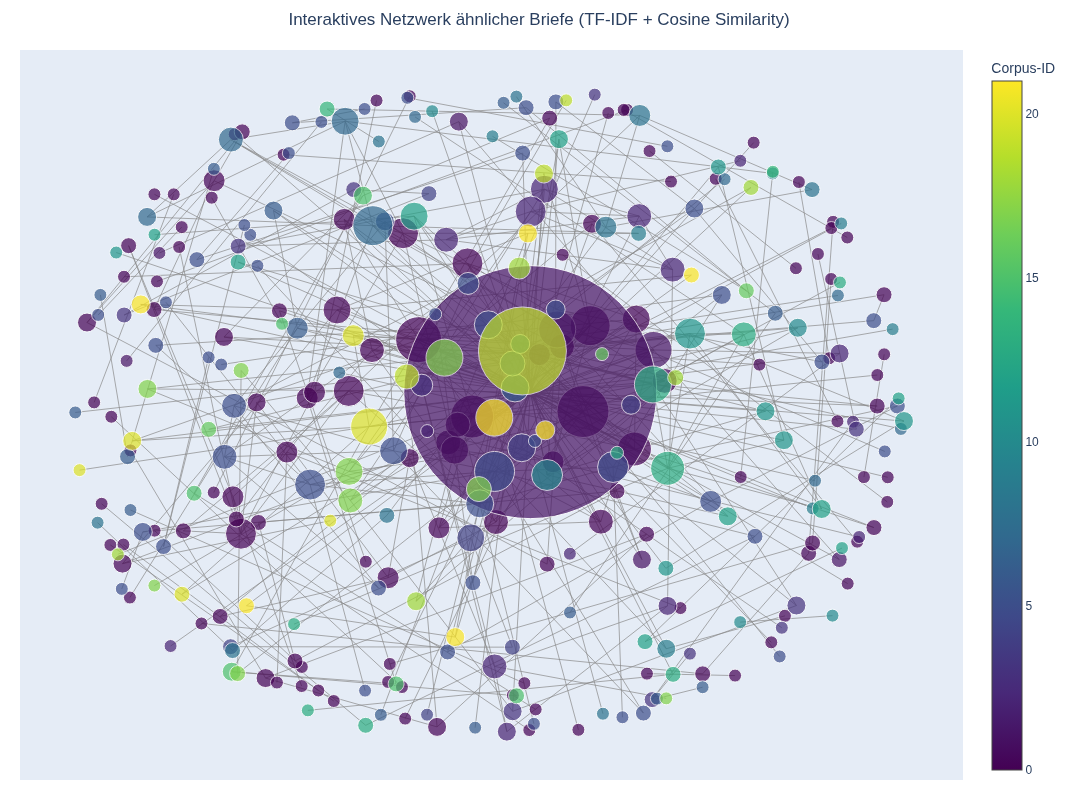

In [186]:
import plotly.graph_objects as go

print(f"Dokumente im Netzwerk: {len(doc_ids_net)}")

# -----------------------------
# 1. Netzwerk aufbauen
# -----------------------------
threshold = 0.20

G = nx.Graph()

for doc_id in doc_ids_net:
    G.add_node(doc_id)

n = len(doc_ids_net)
for i in range(n):
    for j in range(i + 1, n):
        sim = sim_matrix[i, j]
        if sim >= threshold:
            G.add_edge(doc_ids_net[i], doc_ids_net[j], weight=float(sim))

print(f"Knoten: {G.number_of_nodes()}")
print(f"Kanten: {G.number_of_edges()}")

# Optional: Isolates entfernen
G_plot = G.copy()
isolates = list(nx.isolates(G_plot))
G_plot.remove_nodes_from(isolates)

print(f"Ohne Isolates -> Knoten: {G_plot.number_of_nodes()}, Kanten: {G_plot.number_of_edges()}")

# -----------------------------
# 3. Layout berechnen
# -----------------------------
pos = nx.spring_layout(G_plot, seed=42, k=0.35)

# -----------------------------
# 4. Edge-Trace
# -----------------------------
edge_x = []
edge_y = []
edge_text = []

for u, v, data in G_plot.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])
    edge_text.append(f"{u} ↔ {v}<br>similarity={data['weight']:.3f}")

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    line=dict(width=0.7, color="#888"),
    hoverinfo="none",
    mode="lines"
)

# -----------------------------
# 5. Node-Trace
# -----------------------------
node_x = []
node_y = []
node_text = []
node_size = []
node_color = []

degrees = dict(G_plot.degree())

for node in G_plot.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

    deg = degrees[node]
    node_size.append(10 + deg * 3)
    node_color.append(deg)

    node_text.append(
        f"<b>{node}</b><br>"
        f"Degree: {deg}"
    )

corpus_map = dict(zip(df_topics["doc_id"], df_topics["corpus"]))

unique_corpora = sorted(set(corpus_map.get(node, "unknown") for node in G_plot.nodes()))
corpus_to_int = {c: i for i, c in enumerate(unique_corpora)}

node_color = [corpus_to_int.get(corpus_map.get(node, "unknown"), 0) for node in G_plot.nodes()]
node_text = [
    f"<b>{node}</b><br>Corpus: {corpus_map.get(node, 'unknown')}<br>Degree: {degrees[node]}"
    for node in G_plot.nodes()
]

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode="markers+text",
    text=["" for _ in G_plot.nodes()],   # leer; Labels nur bei Hover
    hoverinfo="text",
    hovertext=node_text,
    marker=dict(
    showscale=True,
    colorscale="Viridis",
    color=node_color,
    size=node_size,
    colorbar=dict(title="Corpus-ID"),
    line_width=1
)
)

# -----------------------------
# 6. Figure
# -----------------------------
fig = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title="Interaktives Netzwerk ähnlicher Briefe (TF-IDF + Cosine Similarity)",
        title_x=0.5,
        showlegend=False,
        hovermode="closest",
        margin=dict(b=20, l=20, r=20, t=50),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        height=800
    )
)

fig.show()

In [187]:
from pyvis.network import Network

net = Network(height="800px", width="100%", notebook=True, cdn_resources="in_line")

for node in G_plot.nodes():
    net.add_node(
        node,
        label=node,
        title=f"{node}<br>Degree: {degrees[node]}",
        value=degrees[node]
    )

for u, v, data in G_plot.edges(data=True):
    net.add_edge(u, v, value=data["weight"], title=f"similarity={data['weight']:.3f}")

net.show("letter_network.html")

letter_network.html


In [188]:
list(df_topics[df_topics['doc_id'] == 'ad_familiares_b13.0_l38_r317']['clean_text'])

['Lucius Bruttius eques romanus adulescens res orno familiarissimus obseruo pater magnus amicitia quaestura siciliensis Bruttius Roma mecus domus res familiaris procurator commendo maior studium commendo possum gratus facio curo intellego Bruttius recipio commendatio magnus adiumentum']

In [189]:
list(df_topics[df_topics['doc_id'] == 'ad_familiares_b13.0_l46_r325']['clean_text'])

['Lucius Nostius Zoilus coheres heres patronus res scribo causa amicitia scio homo probus existimo patronus iudicium orno commendo domus gratus curo intellego commendatio magnus adiumentum']

## 9b. BERTopic initialisieren

Für BERTopic verwenden wir:
- einen **SentenceTransformer** für Embeddings
- einen **CountVectorizer** für die c-TF-IDF-Komponente
- einige einfache Parameter, damit das Modell nicht zu fein granuliert

**Wichtiger methodischer Hinweis:**  
Für Latein gibt es nicht dieselbe bequeme Modelllandschaft wie für Englisch. Deshalb ist das hier ein **pragmatischer, explorativer Ansatz**. Für belastbare Forschung müsstest du verschiedene Einstellungen vergleichen und die Topics historisch-philologisch validieren.


In [109]:
from sklearn.feature_extraction.text import CountVectorizer

try:
    from sentence_transformers import SentenceTransformer
    embedding_model = SentenceTransformer("LaBSE")
    print("Embedding-Modell geladen.")
except Exception as e:
    embedding_model = None
    print("Kein SentenceTransformer geladen. BERTopic läuft dann nur mit Vektorraum-/c-TF-IDF-Komponenten.")
    print(type(e).__name__, e)

2026-03-16 00:44:57.709776: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-16 00:44:57.915104: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773618298.005241   18257 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773618298.030617   18257 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-16 00:44:58.229813: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Embedding-Modell geladen.


In [111]:
from bertopic import BERTopic
from hdbscan import HDBSCAN

In [112]:
from umap import UMAP

In [190]:
umap_model = UMAP(
    n_neighbors=15,      # eher 15–30 testen
    n_components=5,      # für Clustering oft stabiler als 2/3
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=8,   # eher 12–20 testen
    min_samples=3,         # konservativer als None
    metric="euclidean",    # auf UMAP-Reduktion üblich
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    lowercase=False,                 # falls du schon normalisierte Lemmata hast
    token_pattern=r"(?u)\b\w+\b",
    ngram_range=(1, 2),              # bei Cicero oft hilfreich
    min_df=3,                        # bei sehr kleinem Korpus evtl. 2
    max_df=0.6
)

In [191]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    hdbscan_model=hdbscan_model,
    umap_model=umap_model,
    vectorizer_model=vectorizer_model,
    #language="multilingual",
    calculate_probabilities=True,
    verbose=True,
)

topics, probs = topic_model.fit_transform(df_topics["topic_text"])
df_topics["topic"] = topics
df_topics["topic_prob"] = [float(np.max(p)) if p is not None else np.nan for p in probs]
df_topics[["doc_id", "topic", "topic_prob", "topic_text"]].head()


2026-03-16 01:27:42,556 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

2026-03-16 01:27:48,614 - BERTopic - Embedding - Completed ✓
2026-03-16 01:27:48,614 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-16 01:27:50,859 - BERTopic - Dimensionality - Completed ✓
2026-03-16 01:27:50,860 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-16 01:27:50,912 - BERTopic - Cluster - Completed ✓
2026-03-16 01:27:50,914 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-16 01:27:51,052 - BERTopic - Representation - Completed ✓


,doc_id,topic,topic_prob,topic_text
0,ad_atticum_bx_l10_r440,-1,0.059856,Tusculanum Ceramicus Roma puer soror mitto epistula adlatus do nuntio dies meridies eo proficiscor facio epistola re...
1,ad_atticum_bx_l10_r460,-1,0.052962,uolo amo constantia ludus Antium specto placeo uolo uito delicia suspicio peregrinor res nonus Maius Formianum exspe...
2,ad_atticum_bx_l10_r485,8,0.056341,ago dies Kalendae iunius cognosco reliquus exspecto placeo Thessalonica adlatus statuo possum causa ago spes uideo o...
3,ad_atticum_bx_l10_r514,6,1.000000,Puteoli magnus rumor Ptolomaeus regnum habeo certior uolo scio pasco bibliotheca Faustus puto res Puteolanus Lucrine...
4,ad_atticum_bx_l10_r533,19,0.139501,Athenae dies Kalendae Quintilis uenio exspecto quartus dies Pomptinus aduentus certum habeo credo uestigium monitus ...


## 10. Erste Sicht auf die Topics


In [192]:
topic_info = topic_model.get_topic_info()
topic_info.head(20)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,368,-1_perscribo_fortuna_Italia_amicitia,"[perscribo, fortuna, Italia, amicitia, ciuitas, audeo, res pus, aetas, pus, Clodius]",[accipio Idus sextilis epistula mitto obiurgo rogo firmus Crassus libertus aio sollicitudo macies narro tertius demo...
1,0,55,0_ualetudo_Tullia_cura ualeo_Situlum,"[ualetudo, Tullia, cura ualeo, Situlum, certior facio, emo, signum, solitudo, viuus, facio certior]","[Situlum tabellarius exspecto uenio certior facio facio certior ualetudo cura ualeo kendae Septemb, Sestius absoluo ..."
2,1,46,1_commendatio_amicitia_necessitudo_patronus,"[commendatio, amicitia, necessitudo, patronus, maior modus, commendo maior, gratus facio, curo intellego, orno, obse...",[dubito observantia necessitudo commendatio memoria teneo Lucius Oppius familiaris praesens Lucius Egnatius familiar...
3,2,46,2_consolatio_fortuna_consolor_exitus,"[consolatio, fortuna, consolor, exitus, leuo, miseria, malus, lepidus, uictoria, domesticus]",[renuntio obitus Tullia filia debeo fero communis calamitas existimo adsum desum dolor declaro genus consolatio mise...
4,3,38,3_dies Kalendae_Crassus_reduco_comitia,"[dies Kalendae, Crassus, reduco, comitia, mandatum, Aulus, Brundisium, Hortensius, Domitius, Aulus dies]",[puto existimo obliuiscor consuetudo institutum soleo locus iter habeo certum uideo Epirus Athenae Asia prŏficiscens...
5,4,34,4_Brutus Cassius_Buthrotum_Hirtius_Buthrotiae,"[Brutus Cassius, Buthrotum, Hirtius, Buthrotiae, Tusculanum, balbus, Tiro, ludus, Plancus, contio]",[Nonae Quintilis uenio puteolanus iens Brutus Nesides dies uenio ceno erus itanus Nonae iulius deus stomachor dies l...
6,5,30,5_rex_Cilicia_Cappadocia_Parthi,"[rex, Cilicia, Cappadocia, Parthi, copia, Scaptius, oppidum, Amanus, Syria, Deiotarus]",[Epirus saluus uenio sententia nauigo gaudeo Roma tempus pernecessarius fero consolor spero hiemo requiesco Gaius Ca...
7,6,26,6_Uarro_Lucullus_Catulus_describo,"[Uarro, Lucullus, Catulus, describo, librarius, Tusculanus, Corinthus, Hortensius, coheres, Dicaearchus]",[uerbum otium nanciscor Brutus puer Laudicea conuenio Roma propero dico Brutus do legatus Appianus uolumen plenus qu...
8,7,24,7_Dolabella_pax_populus Romanus_ciuitas,"[Dolabella, pax, populus Romanus, ciuitas, Romanus, arma, uictoria, dux, pus, poena]",[habeo fama declaro cognosco senatus auctoritas Italia adduco exercitus facio maturo magnus opus desidero res public...
9,8,22,8_Thessalonica_luctus_dies kendae_Epirus,"[Thessalonica, luctus, dies kendae, Epirus, Terentia, uilla, uenio dies, fundus, datum, Oppius]",[Brundisium proficiscor causa Epirus proficiscor Achaia plenus audacissimus inimicus exitus difficilis habeo profici...


In [193]:
# Lesbare Top-Wörter pro Topic
for topic_id in topic_info["Topic"].head(12):
    if topic_id == -1:
        continue
    print(f"\nTOPIC {topic_id}")
    print(topic_model.get_topic(topic_id)[:12])



TOPIC 0
[('ualetudo', 0.0344493587912698), ('Tullia', 0.025737275470864625), ('cura ualeo', 0.025594086687471415), ('Situlum', 0.023051308040649653), ('certior facio', 0.02277945463115028), ('emo', 0.02215238429921722), ('signum', 0.021807434355785204), ('solitudo', 0.018491975071673942), ('viuus', 0.01747874454569577), ('facio certior', 0.016566062683347368)]

TOPIC 1
[('commendatio', 0.08305482323030956), ('amicitia', 0.048576017055416795), ('necessitudo', 0.04677728526542923), ('patronus', 0.043454063809638475), ('maior modus', 0.04229097166280473), ('commendo maior', 0.0385421423266856), ('gratus facio', 0.03753894223559451), ('curo intellego', 0.03143715267261512), ('orno', 0.029926436912231704), ('obseruo', 0.02952408080454956)]

TOPIC 2
[('consolatio', 0.023221677004276405), ('fortuna', 0.01880438738305713), ('consolor', 0.016399800262123065), ('exitus', 0.014355014055452373), ('leuo', 0.013478925828133932), ('miseria', 0.013343606077503933), ('malus', 0.013131103504237285), ('

## 11. Topic-Grössen visualisieren


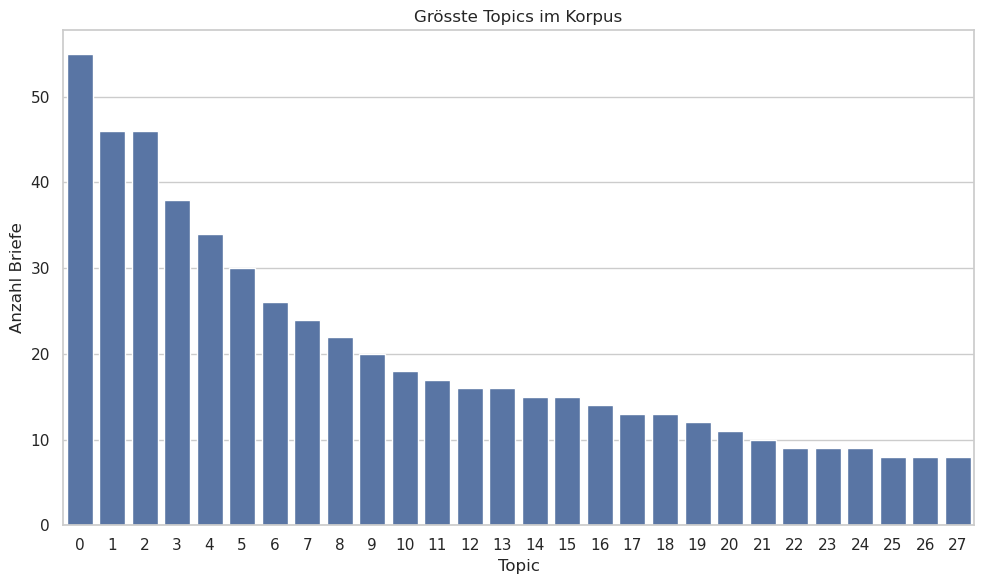

In [194]:
topic_sizes = topic_info[topic_info["Topic"] != -1].copy()

plt.figure(figsize=(10, 6))
sns.barplot(data=topic_sizes, x="Topic", y="Count")
plt.title("Grösste Topics im Korpus")
plt.xlabel("Topic")
plt.ylabel("Anzahl Briefe")
plt.tight_layout()
plt.show()


## 12. Interaktive BERTopic-Visualisierungen

Die folgenden Visualisierungen sind besonders nützlich:
- **Topic map**: räumliche Nähe zwischen Topics
- **Barchart**: wichtigste Wörter pro Topic
- **Hierarchy**: Themen-Hierarchie
- **Heatmap**: Ähnlichkeit zwischen Topics

In Jupyter werden sie interaktiv angezeigt. Zusätzlich speichern wir sie als HTML.


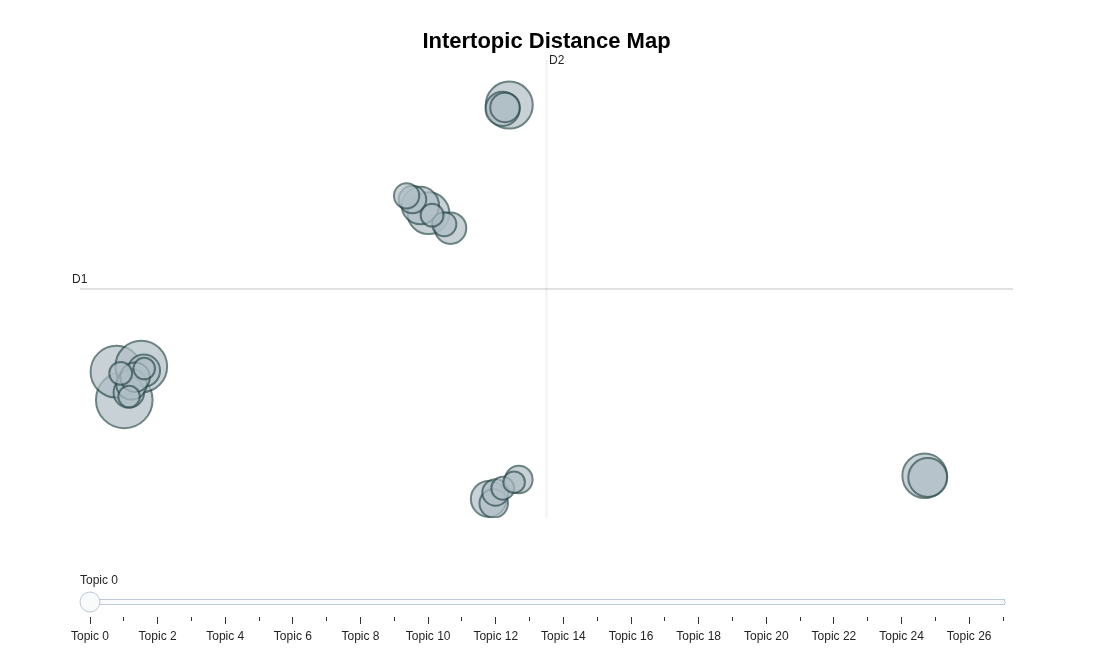

In [195]:
fig_topics = topic_model.visualize_topics()
fig_topics


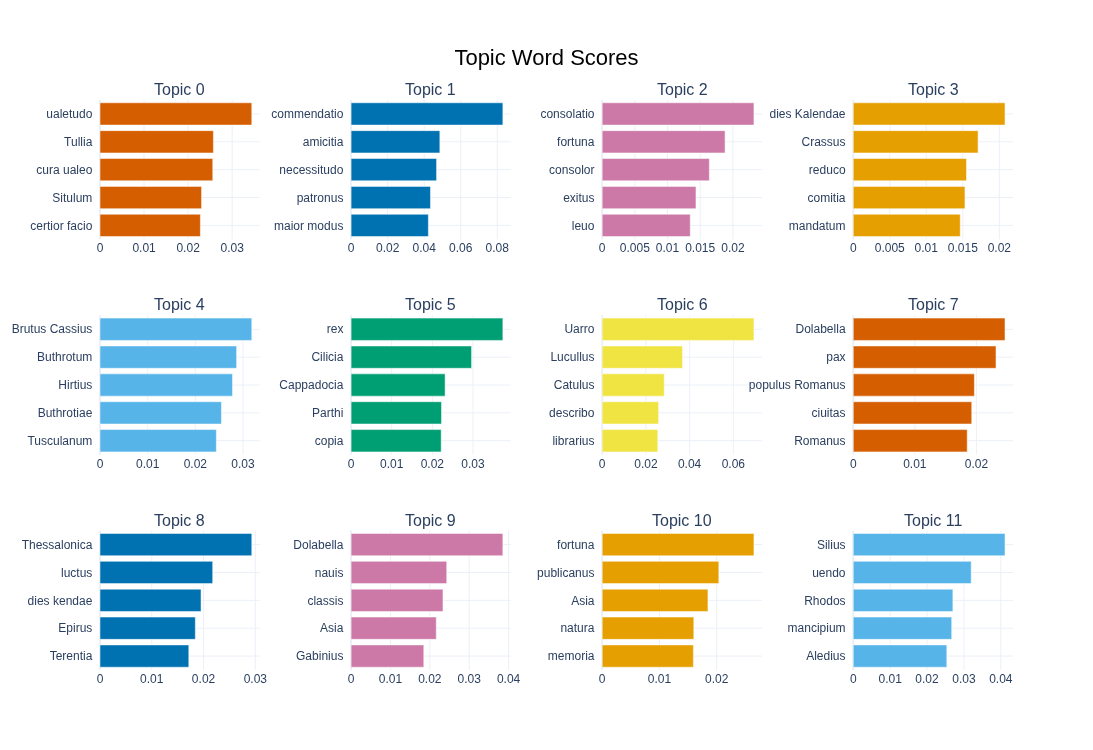

In [196]:
fig_barchart = topic_model.visualize_barchart(top_n_topics=12)
fig_barchart


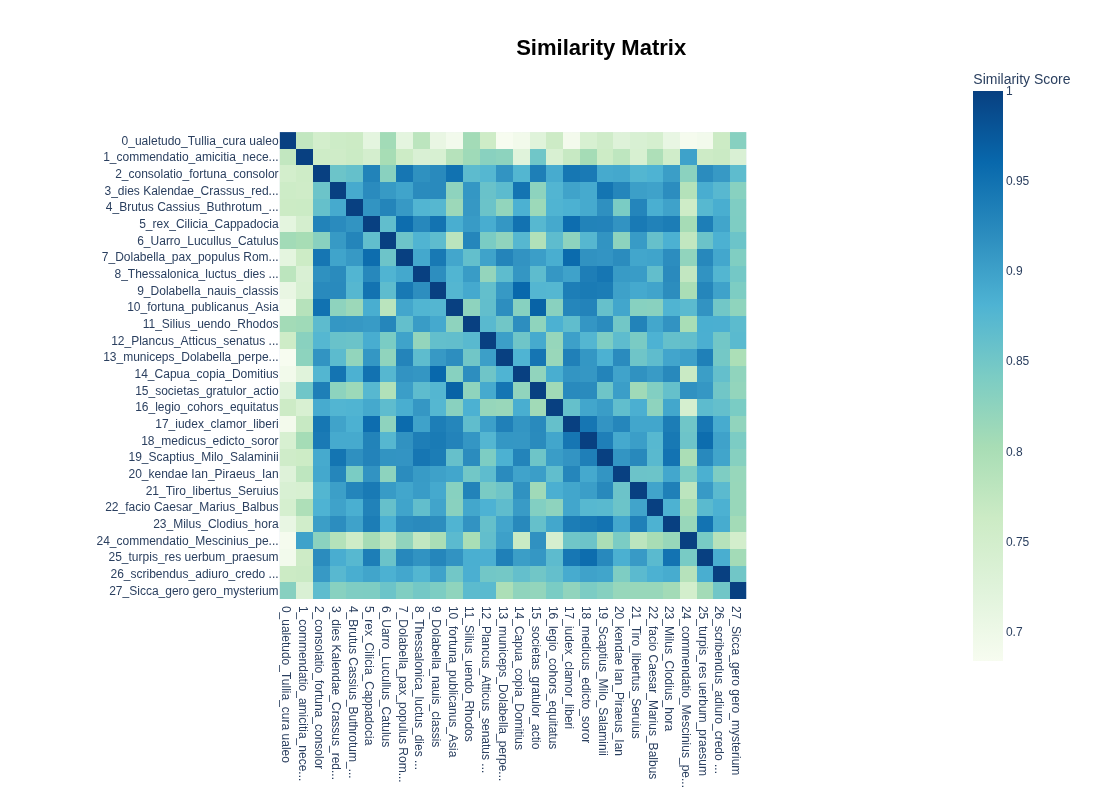

In [197]:
fig_heatmap = topic_model.visualize_heatmap()
fig_heatmap


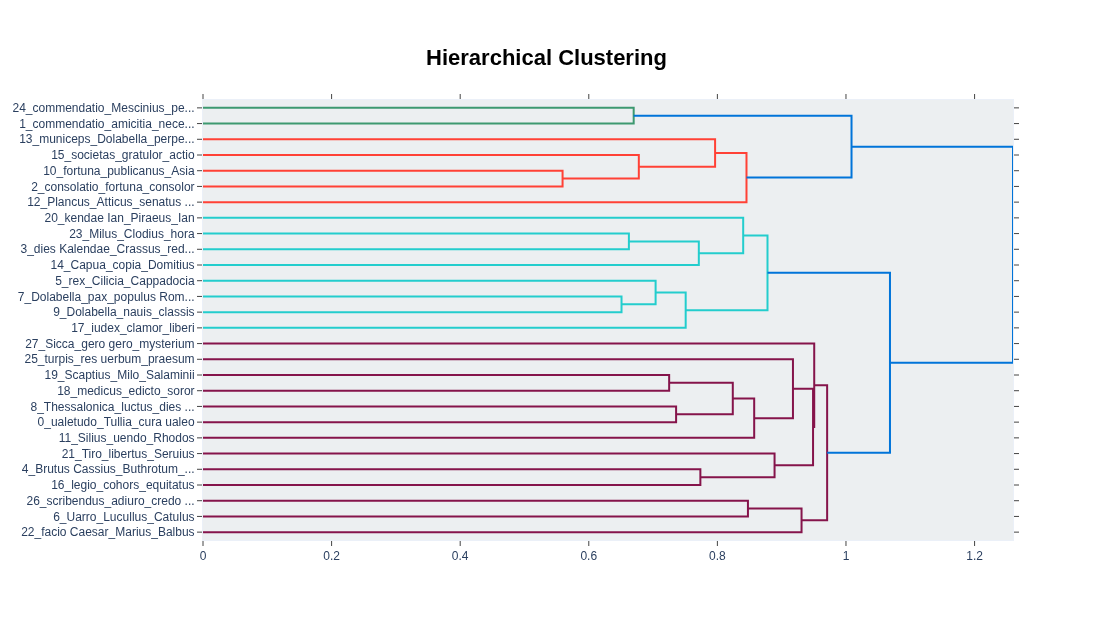

In [198]:
fig_hierarchy = topic_model.visualize_hierarchy()
fig_hierarchy


In [199]:
fig_topics.write_html(str(topic_dir / "bertopic_topics_map.html"))
fig_barchart.write_html(str(topic_dir / "bertopic_barchart.html"))
fig_heatmap.write_html(str(topic_dir / "bertopic_heatmap.html"))
fig_hierarchy.write_html(str(topic_dir / "bertopic_hierarchy.html"))

sorted(topic_dir.glob("*.html"))


[PosixPath('outputs/topic_modeling/bertopic_barchart.html'),
 PosixPath('outputs/topic_modeling/bertopic_heatmap.html'),
 PosixPath('outputs/topic_modeling/bertopic_hierarchy.html'),
 PosixPath('outputs/topic_modeling/bertopic_topics_map.html')]

## 13. Topics pro Subkorpus

Jetzt prüfen wir, ob einzelne Subkorpora andere Topic-Schwerpunkte haben.


In [200]:
topic_by_corpus = (
    df_topics.groupby(["corpus", "topic"])
    .size()
    .reset_index(name="n")
)

topic_pivot = topic_by_corpus.pivot(index="corpus", columns="topic", values="n").fillna(0)
topic_pivot


topic,-1,0,1,2,3,4,5,6,7,8,...,18,19,20,21,22,23,24,25,26,27
corpus,,,,,,,,,,,,,,,,,,,,,
ad_atticum,174.0,28.0,1.0,15.0,24.0,27.0,9.0,25.0,3.0,18.0,...,9.0,11.0,3.0,9.0,6.0,6.0,0.0,3.0,5.0,7.0
ad_familiares_b1,4.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ad_familiares_b10,14.0,0.0,0.0,3.0,0.0,0.0,1.0,0.0,3.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ad_familiares_b11,9.0,1.0,1.0,4.0,0.0,2.0,1.0,0.0,3.0,0.0,...,0.0,0.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
ad_familiares_b12,17.0,0.0,1.0,2.0,1.0,2.0,2.0,0.0,2.0,0.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ad_familiares_b13,23.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0
ad_familiares_b14,6.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ad_familiares_b15,9.0,1.0,1.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0
ad_familiares_b16,14.0,5.0,0.0,0.0,2.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


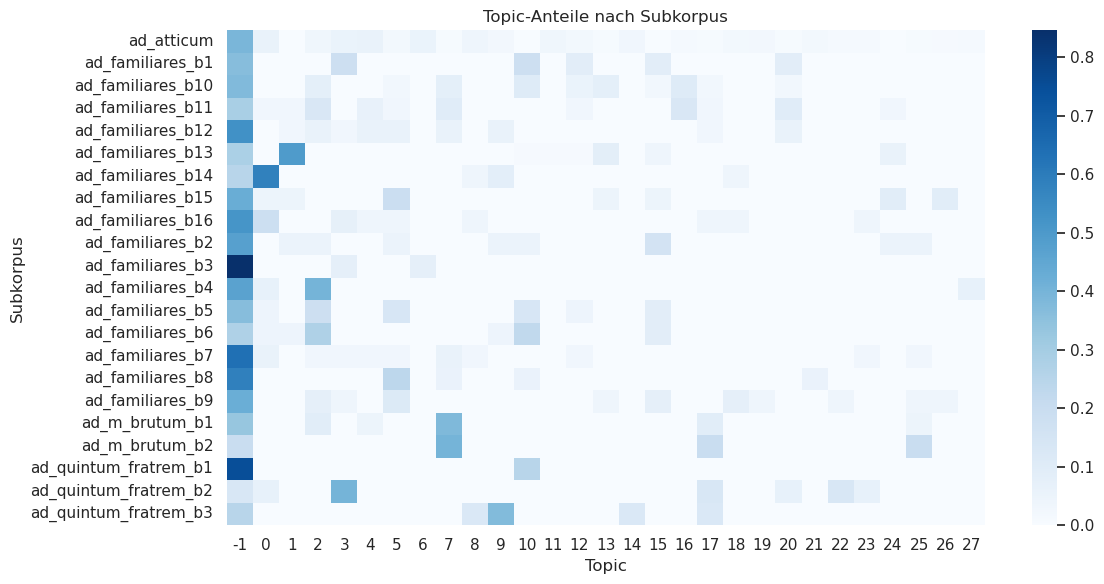

In [201]:
topic_share = topic_pivot.div(topic_pivot.sum(axis=1), axis=0)

plt.figure(figsize=(12, 6))
sns.heatmap(topic_share, cmap="Blues")
plt.title("Topic-Anteile nach Subkorpus")
plt.xlabel("Topic")
plt.ylabel("Subkorpus")
plt.tight_layout()
plt.show()


## 14. Topics über die Zeit

Falls dein Datensatz eine brauchbare Datumsangabe enthält, kannst du Topics auch zeitlich untersuchen.

Da antike Datierungen oft unregelmässig sind, gehen wir bewusst defensiv vor:
- wir extrahieren, wenn möglich, ein Jahr aus `date_when`
- dann zählen wir Topics pro Jahr


In [202]:
def extract_year(value):
    if pd.isna(value):
        return np.nan
    value = str(value)

    # einfache Heuristik: erste 1-4 Ziffern greifen
    m = re.search(r"(-?\d{1,4})", value)
    if m:
        try:
            return int(m.group(1))
        except Exception:
            return np.nan
    return np.nan

if "date_when" in df_topics.columns:
    df_topics["year_simple"] = df_topics["date_when"].apply(extract_year)
else:
    df_topics["year_simple"] = np.nan

df_topics[["date_when", "year_simple"]].head(10)


,date_when,year_simple
0,-67.0,-67.0
1,NaN,NaN
2,-58.0,-58.0
3,NaN,NaN
4,-51.0,-51.0
5,-49.0,-49.0
6,NaN,NaN
7,-49.0,-49.0
8,NaN,NaN
9,-47.0,-47.0


In [203]:
time_df = df_topics.dropna(subset=["year_simple"]).copy()
time_df["year_simple"] = time_df["year_simple"].astype(int)

topic_year = (
    time_df.groupby(["year_simple", "topic"])
    .size()
    .reset_index(name="n")
)

topic_year.head()


,year_simple,topic,n
0,-67,-1,5
1,-67,1,1
2,-67,3,1
3,-67,18,1
4,-66,20,1


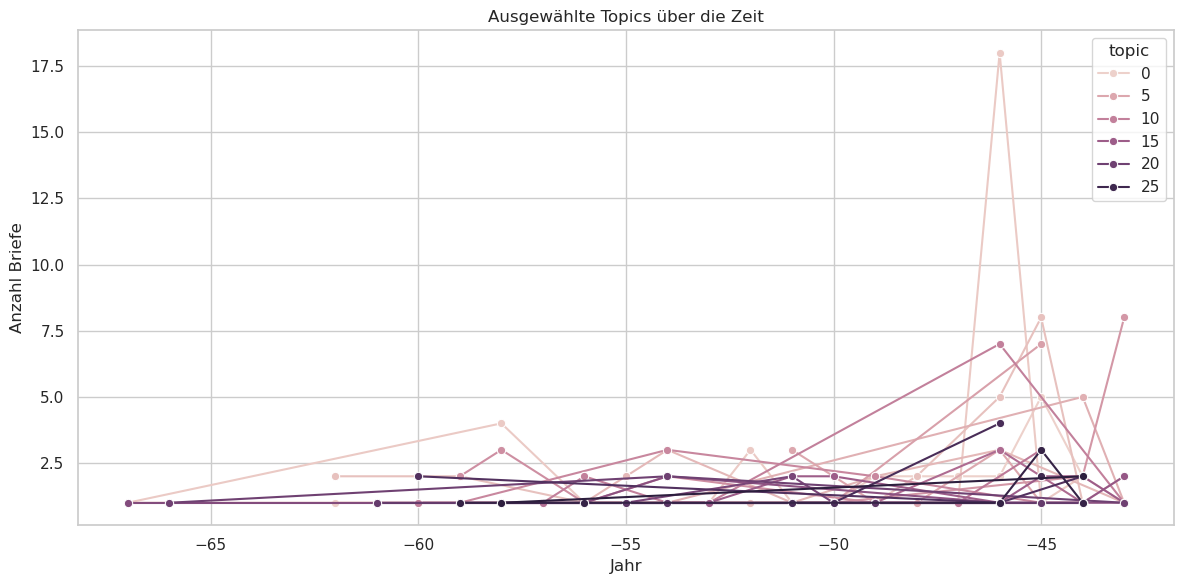

In [205]:
# Nur die häufigsten Topics darstellen
top_topics = topic_info[topic_info["Topic"] != -1]["Topic"].tolist()
plot_df = topic_year[topic_year["topic"].isin(top_topics)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x="year_simple", y="n", hue="topic", marker="o")
plt.title("Ausgewählte Topics über die Zeit")
plt.xlabel("Jahr")
plt.ylabel("Anzahl Briefe")
plt.tight_layout()
plt.show()


## 15. Repräsentative Briefe pro Topic finden

Für die Interpretation ist es hilfreich, pro Topic ein paar Beispielbriefe anzuschauen.


In [207]:
rep_docs = []
for topic_id in sorted(df_topics["topic"].unique()):
    if topic_id == -1:
        continue
    sub = df_topics[df_topics["topic"] == topic_id].copy()
    sub = sub.sort_values("topic_prob", ascending=False).head(3)
    rep_docs.append(sub[["doc_id", "corpus", "topic", "topic_prob", "topic_text"]])

rep_docs_df = pd.concat(rep_docs, ignore_index=True) if rep_docs else pd.DataFrame()
rep_docs_df.head(20)


,doc_id,corpus,topic,topic_prob,topic_text
0,ad_atticum_bx_l53_r740,ad_atticum,0,1.0,habeo loquor uideo Nicias Ualerius exspecto matutinus posmeridianus epiroticus impedio interpello mitto epistula Mar...
1,ad_atticum_bx_l50_r737,ad_atticum,0,1.0,leuo aduentus discessus adfiigo res possum Sextus auctio opera do reuiso dies utilis dica gratus Roma uenio consultu...
2,ad_familiares_b14.0_l16_r374,ad_familiares_b14,0,1.0,Situlum modus tempus habeo exspecto nescio modus exspecto habeo fero uolumnium debeo officiosus facio possum facio c...
3,ad_atticum_bx_l7_r437,ad_atticum,1,1.0,mater cura Lucius Cincius constituo curo Idus uolo emo paro do opera habeo uolo cogito polliceor modus bibliotheca c...
4,ad_familiares_b13.0_l40_r319,ad_familiares_b13,1,1.0,Lucius Gaius Aurelius Lucius filius pater uir optimus utor commendo maior modus adulescens optimus ars orno perneces...
5,ad_familiares_b13.0_l42_r321,ad_familiares_b13,1,1.0,Lucius Lucceius familiaris hQmO gratus mirifico gratia ago dico liberalissimus procurator polliqior oratio gratus gr...
6,ad_atticum_bx_l4_r636,ad_atticum,2,1.0,accipio epistula dies uolumen instar legendus facio labor suscipio pergratus facio res licet scio facio rogo deploro...
7,ad_atticum_bx_l11_r666,ad_atticum,2,1.0,conficio cruciatus maximus dolor debeo exsequor possum res scribendus spes ostendo melior exspecto adfero uolo res d...
8,ad_atticum_bx_l1_r655,ad_atticum,2,1.0,accipio signo libellus Anteri adfero scio possum domesticus res adflictor dispenso adsum terra scio spes habeo exist...
9,ad_atticum_bx_l7_r530,ad_atticum,3,1.0,dies singulus breuior mitto suspicor Epirus proficiscor mandatum scio curo aio Pompeius quini praefectus defero nouu...


## 16. Ergebnisse speichern

Wir sichern:
- Topic-Zuweisungen pro Brief
- Topic-Informationen
- repräsentative Briefe


In [208]:
df_topics.to_csv(topic_dir / "letters_with_topics.csv", index=False)
topic_info.to_csv(topic_dir / "topic_info.csv", index=False)
rep_docs_df.to_csv(topic_dir / "representative_docs_per_topic.csv", index=False)

sorted(topic_dir.glob("*.csv"))


[PosixPath('outputs/topic_modeling/letters_with_topics.csv'),
 PosixPath('outputs/topic_modeling/representative_docs_per_topic.csv'),
 PosixPath('outputs/topic_modeling/topic_info.csv')]

## 17. Methodische Reflexion

Ein paar Punkte, die du bei der Interpretation im Hinterkopf behalten solltest:

1. **Topics sind keine objektiven Wahrheiten**, sondern modellierte Wortbündel.
2. Bei **lateinischen Texten** hängt sehr viel an der Qualität von Lemmatisierung und POS-Tagging.
3. BERTopic ist stark, aber nicht magisch:
   - andere Parameter erzeugen andere Topics
   - auch die Vorverarbeitung beeinflusst das Ergebnis massiv
4. Gerade für den Kurs ist die Kombination aus
   - **philologischer Nahlektüre**
   - **linguistischer Vorverarbeitung**
   - **explorativer Modellierung**
   besonders fruchtbar.

Mit Blick auf White liesse sich nun z.B. fragen:
- Dominieren politische Topics?
- Unterscheiden sich Topics je nach Subkorpus?
- Entstehen Topic-Cluster, die editorische oder historische Episoden spiegeln?


## 18. Topic Modelling mit gensim

In [219]:
import pandas as pd
from gensim import corpora, models
from gensim.models import CoherenceModel
from pprint import pprint
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# =========================
# 1. Texte vorbereiten
# =========================
text_col = "topic_text"   # ggf. anpassen
id_col = "doc_id"         # ggf. anpassen

# nur brauchbare Texte behalten
df_lda = df_topics[[id_col, text_col]].dropna().copy()
df_lda = df_lda[df_lda[text_col].str.strip() != ""]

# tokenisieren
texts = [text.split() for text in df_lda[text_col]]

# sehr kurze Dokumente entfernen
min_tokens = 5
valid_mask = [len(toks) >= min_tokens for toks in texts]
texts = [toks for toks, keep in zip(texts, valid_mask) if keep]
df_lda = df_lda.loc[df_lda.index[valid_mask]].reset_index(drop=True)

print(f"Dokumente für LDA: {len(texts)}")

# =========================
# 2. Dictionary + Corpus
# =========================
dictionary = corpora.Dictionary(texts)

# Extremwerte filtern
# no_below: mindestens in X Dokumenten
# no_above: in höchstens Y Anteil der Dokumente
dictionary.filter_extremes(no_below=5, no_above=0.5, keep_n=5000)

corpus = [dictionary.doc2bow(text) for text in texts]

print(f"Vokabulargrösse: {len(dictionary)}")

# =========================
# 3. LDA trainieren
# =========================
num_topics = 20  # ggf. variieren

lda_model = models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    chunksize=100,
    passes=20,
    iterations=400,
    alpha="auto",
    eta="auto",
    per_word_topics=True
)

# =========================
# 4. Topics ausgeben
# =========================
print("\nTopics:\n")
for i, topic in lda_model.print_topics(num_topics=num_topics, num_words=10):
    print(f"Topic {i}: {topic}")

# =========================
# 5. Kohärenz berechnen
# =========================
coherence_model = CoherenceModel(
    model=lda_model,
    texts=texts,
    dictionary=dictionary,
    coherence="c_v"
)
coherence = coherence_model.get_coherence()
print(f"\nCoherence (c_v): {coherence:.4f}")

# =========================
# 6. Dominantes Topic pro Dokument
# =========================
def get_dominant_topic(bow):
    topic_probs = lda_model.get_document_topics(bow, minimum_probability=0.0)
    dominant_topic, dominant_prob = max(topic_probs, key=lambda x: x[1])
    return dominant_topic, dominant_prob

dominant_topic = [get_dominant_topic(bow) for bow in corpus]
print(dominant_topic)
df_lda["dominant_topic"] = [t[0] for t in dominant]
df_lda["topic_prob"] = [t[1] for t in dominant]

display(df_lda.head())

# =========================
# 7. Interaktive Visualisierung
# =========================
vis = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(vis)

Dokumente für LDA: 929
Vokabulargrösse: 2524

Topics:

Topic 0: 0.068*"Pompeius" + 0.067*"Caesar" + 0.038*"dies" + 0.034*"homo" + 0.026*"sermo" + 0.024*"Lentulus" + 0.017*"Roma" + 0.014*"ago" + 0.013*"quaero" + 0.013*"ludus"
Topic 1: 0.162*"Atticus" + 0.082*"facilitas" + 0.070*"viuus" + 0.067*"uituperatio" + 0.052*"noto" + 0.042*"introduco" + 0.040*"cos" + 0.015*"martius" + 0.012*"Buthrotiae" + 0.008*"Siculus"
Topic 2: 0.025*"consilium" + 0.024*"tempus" + 0.018*"scio" + 0.018*"animus" + 0.017*"fero" + 0.014*"spes" + 0.014*"credo" + 0.014*"cogito" + 0.012*"sentio" + 0.012*"accido"
Topic 3: 0.045*"Cicero" + 0.039*"maior" + 0.031*"familiaris" + 0.027*"magnus" + 0.026*"gaudeo" + 0.026*"patior" + 0.021*"diligentia" + 0.021*"Caesar" + 0.019*"beneuolentia" + 0.017*"diligo"
Topic 4: 0.035*"bellum" + 0.027*"Antonius" + 0.025*"exercitus" + 0.019*"consequor" + 0.014*"gero" + 0.014*"pars" + 0.014*"consilium" + 0.014*"relinquo" + 0.014*"copia" + 0.014*"Italia"
Topic 5: 0.112*"honor" + 0.106*"commen

/home/phillip/anaconda3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning:

This process (pid=18257) is multi-threaded, use of fork() may lead to deadlocks in the child.

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/home/phillip/anaconda3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning:

This process (pid=18257) is multi-threaded, use of fork() may lead to deadlocks in the child.

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_P


Coherence (c_v): 0.3603
[(10, 0.49300864), (15, 0.24997622), (12, 0.21972865), (2, 0.21075234), (10, 0.23881038), (2, 0.24815142), (10, 0.26175094), (2, 0.20421153), (15, 0.3286009), (15, 0.25754315), (10, 0.20298621), (2, 0.28504696), (2, 0.39914715), (10, 0.33508715), (3, 0.21346773), (15, 0.16765217), (10, 0.4024888), (4, 0.36654782), (2, 0.17332597), (4, 0.46589422), (10, 0.3189166), (15, 0.3254595), (2, 0.25801662), (15, 0.47147503), (10, 0.38380525), (0, 0.26699486), (2, 0.39004877), (4, 0.3186426), (4, 0.26218322), (10, 0.4088211), (15, 0.24046339), (15, 0.19761673), (2, 0.20626777), (15, 0.23474403), (15, 0.31835154), (4, 0.56705016), (2, 0.5874219), (4, 0.24112299), (4, 0.35256478), (4, 0.44607434), (15, 0.2855184), (15, 0.28330967), (10, 0.20594719), (17, 0.23192808), (15, 0.22312492), (10, 0.23703927), (2, 0.20648937), (0, 0.2379137), (15, 0.23912406), (10, 0.52074367), (0, 0.21758886), (6, 0.36214042), (2, 0.20793505), (15, 0.32352507), (2, 0.2629666), (15, 0.2509268), (4,

,doc_id,topic_text,dominant_topic,topic_prob
0,ad_atticum_bx_l10_r440,Tusculanum Ceramicus Roma puer soror mitto epistula adlatus do nuntio dies meridies eo proficiscor facio epistola re...,10,0.493009
1,ad_atticum_bx_l10_r460,uolo amo constantia ludus Antium specto placeo uolo uito delicia suspicio peregrinor res nonus Maius Formianum exspe...,15,0.249976
2,ad_atticum_bx_l10_r485,ago dies Kalendae iunius cognosco reliquus exspecto placeo Thessalonica adlatus statuo possum causa ago spes uideo o...,12,0.219729
3,ad_atticum_bx_l10_r514,Puteoli magnus rumor Ptolomaeus regnum habeo certior uolo scio pasco bibliotheca Faustus puto res Puteolanus Lucrine...,2,0.210752
4,ad_atticum_bx_l10_r533,Athenae dies Kalendae Quintilis uenio exspecto quartus dies Pomptinus aduentus certum habeo credo uestigium monitus ...,10,0.238810


/home/phillip/anaconda3/lib/python3.12/site-packages/pytz/tzinfo.py:27: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  _epoch = datetime.utcfromtimestamp(0)
/home/phillip/anaconda3/lib/python3.12/site-packages/pytz/tzinfo.py:27: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  _epoch = datetime.utcfromtimestamp(0)
/home/phillip/anaconda3/lib/python3.12/site-packages/pytz/tzinfo.py:27: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  

## 18. Mini-Übungen

1. Verändere die Funktion `prepare_topic_text()`:
   - einmal nur `NOUN` + `PROPN`
   - einmal mit allen alphabetischen Tokens  
   Vergleiche die Topics.

2. Setze `min_topic_size` höher oder tiefer.  
   Wie verändert das die Zahl und Lesbarkeit der Topics?

3. Suche zu **einem** Topic drei Briefe heraus und prüfe per Nahlektüre:
   - Ist das Topic historisch sinnvoll?
   - Ist es zu allgemein?
   - Sind mehrere Topics eigentlich dasselbe?

4. Prüfe, ob ein bestimmtes Subkorpus (z.B. `ad_atticum`) stärker auf einzelne Topics konzentriert ist als andere.


In [210]:
# -----------------------------
# 1. Document-topic matrix
# -----------------------------
doc_topic_matrix = []
for bow in corpus:
    topic_probs = lda_model.get_document_topics(bow, minimum_probability=0.0)
    doc_topic_matrix.append([prob for _, prob in topic_probs])

doc_topic_matrix = np.array(doc_topic_matrix)

topic_cols = [f"topic_{i}" for i in range(lda_model.num_topics)]
doc_topic_df = pd.DataFrame(doc_topic_matrix, columns=topic_cols)
doc_topic_df.insert(0, "doc_id", df_lda["doc_id"].values)

display(doc_topic_df.head())


,doc_id,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,...,topic_10,topic_11,topic_12,topic_13,topic_14,topic_15,topic_16,topic_17,topic_18,topic_19
0,ad_atticum_bx_l10_r440,0.033228,0.000683,0.083661,0.040654,0.045507,0.004296,0.023523,0.014983,0.000999,...,0.493008,0.003797,0.008408,0.002561,0.000358,0.213844,0.001580,0.004215,0.000695,0.000066
1,ad_atticum_bx_l10_r460,0.059907,0.001737,0.197905,0.059717,0.055307,0.010924,0.014307,0.030974,0.002542,...,0.203122,0.010167,0.035945,0.006512,0.000910,0.249975,0.004062,0.037152,0.001769,0.000168
2,ad_atticum_bx_l10_r485,0.035659,0.000773,0.189810,0.046825,0.064761,0.013732,0.006884,0.017399,0.001131,...,0.211404,0.004298,0.219728,0.002898,0.000405,0.163166,0.001789,0.006689,0.000787,0.000075
3,ad_atticum_bx_l10_r514,0.055958,0.001300,0.210753,0.170630,0.080041,0.008188,0.010605,0.027918,0.001902,...,0.154982,0.022039,0.030417,0.004873,0.000681,0.155251,0.003008,0.021620,0.001324,0.000126
4,ad_atticum_bx_l10_r533,0.189472,0.000634,0.146823,0.075498,0.025216,0.004047,0.011127,0.015542,0.000927,...,0.238813,0.010716,0.020293,0.009975,0.000332,0.214312,0.001469,0.004177,0.000645,0.000061


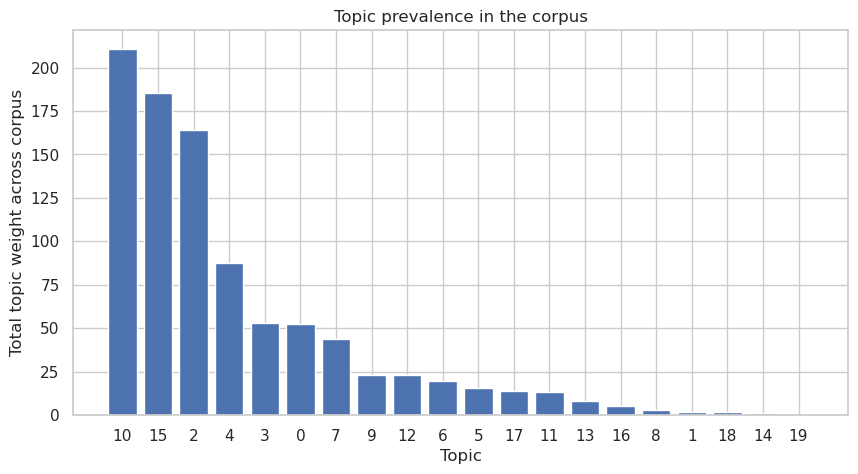

,topic,size
10,10,210.893555
15,15,185.554291
2,2,164.118011
4,4,87.772964
3,3,52.951878
0,0,52.327732
7,7,44.032600
9,9,22.991621
12,12,22.984175
6,6,19.930321


In [211]:
# -----------------------------
# 2. Topic sizes
# -----------------------------
topic_sizes = doc_topic_matrix.sum(axis=0)
topic_size_df = pd.DataFrame({
    "topic": range(lda_model.num_topics),
    "size": topic_sizes
}).sort_values("size", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(topic_size_df["topic"].astype(str), topic_size_df["size"])
plt.xlabel("Topic")
plt.ylabel("Total topic weight across corpus")
plt.title("Topic prevalence in the corpus")
plt.xticks(rotation=0)
plt.show()

display(topic_size_df)

,topic,rank,word,weight
0,0,1,Pompeius,0.067973
1,0,2,Caesar,0.066777
2,0,3,dies,0.038128
3,0,4,homo,0.034119
4,0,5,sermo,0.026134
5,0,6,Lentulus,0.024164
6,0,7,Roma,0.016525
7,0,8,ago,0.013773
8,0,9,quaero,0.013445
9,0,10,ludus,0.012735


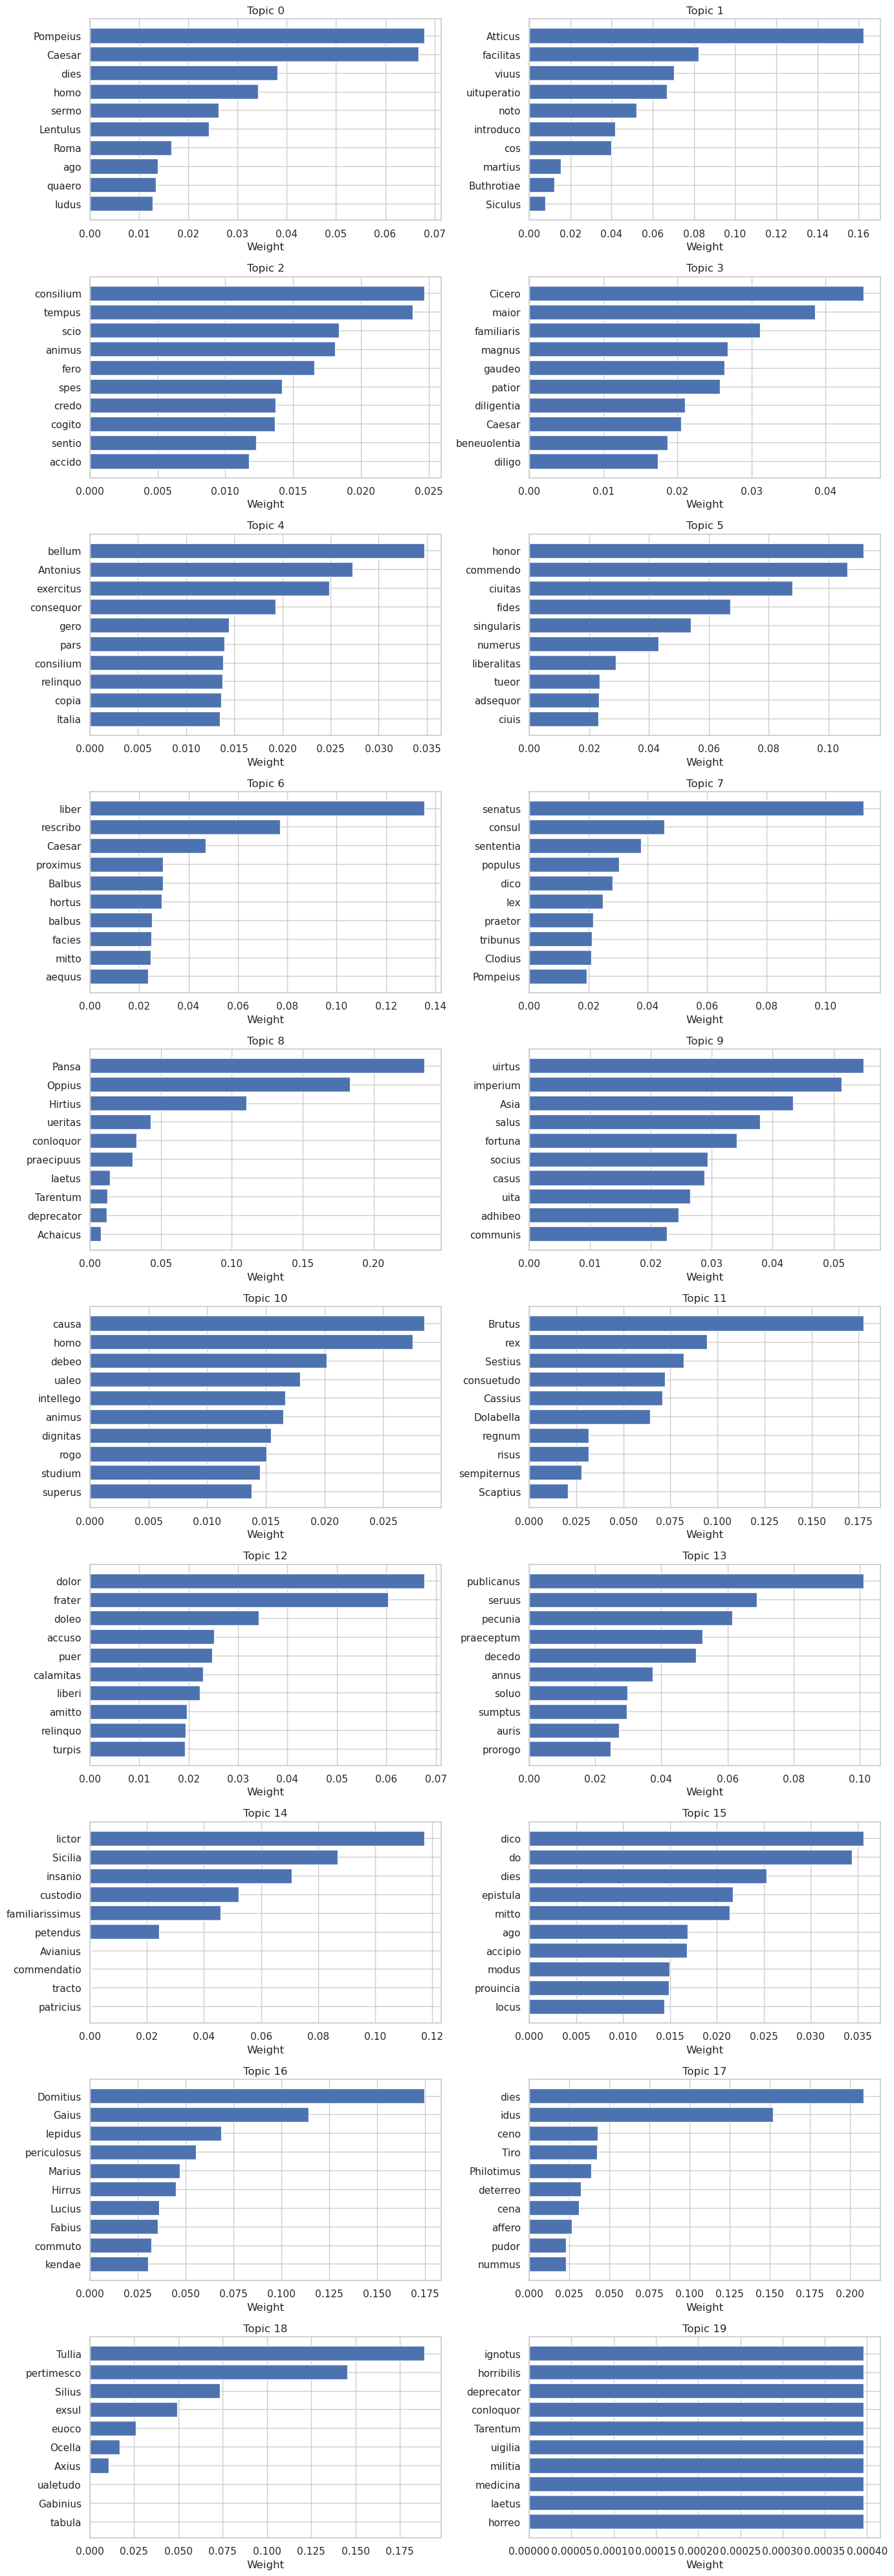

In [212]:
# -----------------------------
# 3. Top words per topic
# -----------------------------
top_n = 10
topic_word_rows = []

for topic_id in range(lda_model.num_topics):
    words = lda_model.show_topic(topic_id, topn=top_n)
    for rank, (word, weight) in enumerate(words, start=1):
        topic_word_rows.append({
            "topic": topic_id,
            "rank": rank,
            "word": word,
            "weight": weight
        })

topic_words_df = pd.DataFrame(topic_word_rows)
display(topic_words_df.head(30))

# small multiples: top words per topic
n_topics = lda_model.num_topics
ncols = 2
nrows = int(np.ceil(n_topics / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).reshape(-1)

for topic_id in range(n_topics):
    ax = axes[topic_id]
    sub = topic_words_df[topic_words_df["topic"] == topic_id].sort_values("weight", ascending=True)
    ax.barh(sub["word"], sub["weight"])
    ax.set_title(f"Topic {topic_id}")
    ax.set_xlabel("Weight")

for j in range(n_topics, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

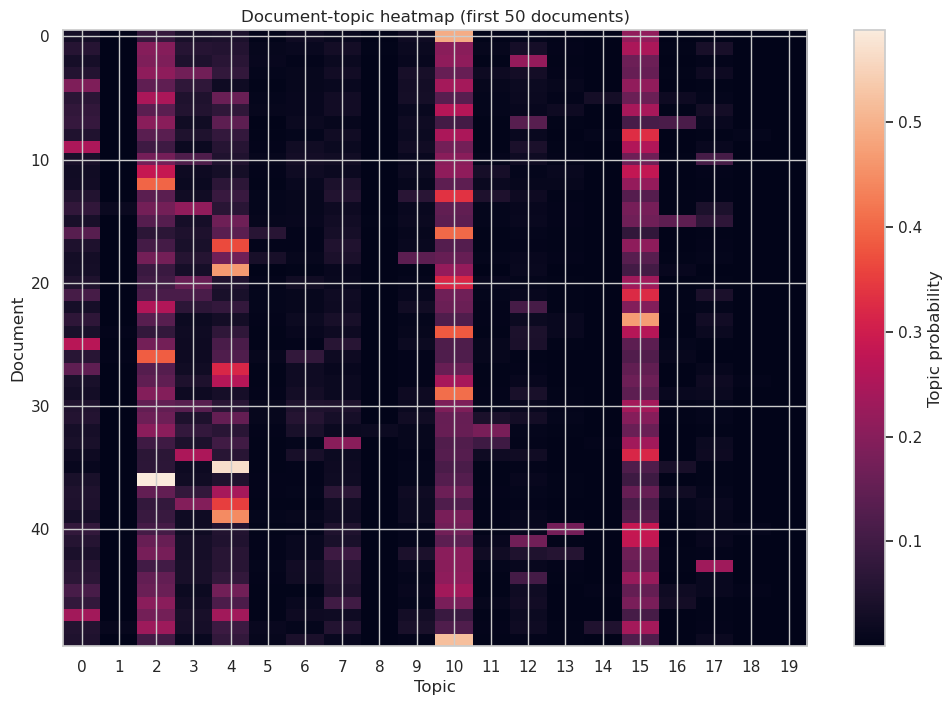

In [213]:
# -----------------------------
# 5. Document-topic heatmap
# -----------------------------
# For readability: show only first N docs
max_docs = min(50, len(doc_topic_df))
heatmap_data = doc_topic_matrix[:max_docs]

plt.figure(figsize=(12, 8))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Topic probability")
plt.xlabel("Topic")
plt.ylabel("Document")
plt.title(f"Document-topic heatmap (first {max_docs} documents)")
plt.xticks(range(lda_model.num_topics), range(lda_model.num_topics))
plt.show()

In [216]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
# -----------------------------
# 6. 2D document map (BERTopic-like document scatter)
# -----------------------------
pca = PCA(n_components=2, random_state=42)
doc_2d = pca.fit_transform(doc_topic_matrix)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    doc_2d[:, 0],
    doc_2d[:, 1],
    c=[dominant_topic,
    s=30 + dominant_prob * 120,
    alpha=0.75
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Documents in topic space (2D projection)")
plt.colorbar(scatter, label="Dominant topic")
plt.show()

NameError: name 'dominant_prob' is not defined

<Figure size 1000x700 with 0 Axes>

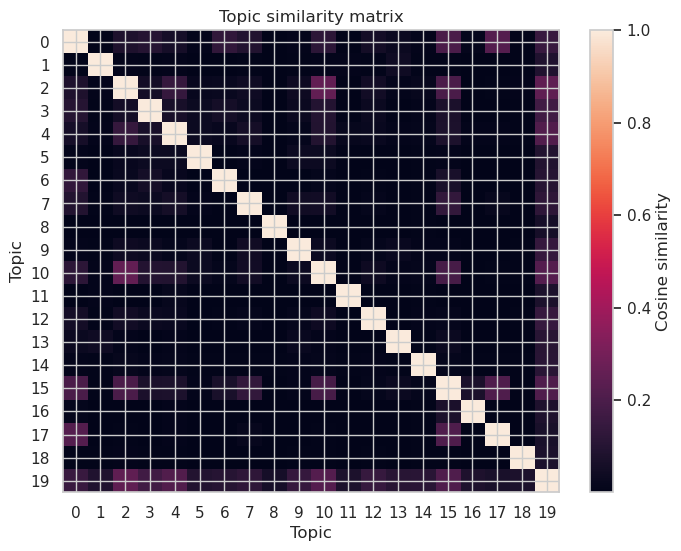

In [220]:
# -----------------------------
# 7. Topic similarity heatmap
# -----------------------------
# topic-word matrix from lda_model.get_topics()
topic_word_matrix = lda_model.get_topics()
topic_similarity = cosine_similarity(topic_word_matrix)

plt.figure(figsize=(8, 6))
plt.imshow(topic_similarity, aspect="auto")
plt.colorbar(label="Cosine similarity")
plt.xticks(range(n_topics), range(n_topics))
plt.yticks(range(n_topics), range(n_topics))
plt.xlabel("Topic")
plt.ylabel("Topic")
plt.title("Topic similarity matrix")
plt.show()